In [9]:
# Data handling
import geopandas as gpd
import numpy as np
import os
import pandas as pd
import pyarrow.compute as pc

# Visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

# Custom functions
from scripts.common_functions import python_setup, get_mms_data, save_figure

# Set up Python
working_dir, charts_dir, data_dir = python_setup(2, dark_mode=False)

# Paths and variables
gen_info_path = os.path.join(data_dir, "gen_info.csv")
duid_data_path = os.path.join(data_dir, "duid_data.parquet")
market_data_path = os.path.join(data_dir, "market_data.parquet")
regions = ["NSW", "QLD", "SA", "VIC"]

# Load gen info
gen_info = pd.read_csv(
    gen_info_path,
    index_col="DUID")

In [10]:
# Generator performance analysis
def generator_analysis(region, tech="Wind", period="quarter"):
    print(f"Plant analysis for", region, tech.lower(), "by", period, "...")
    
    # Filter DUIDs
    def filter_duids(region, tech):
        print("Filtering DUIDs ...")
        duids = gen_info[
            (gen_info["Region"] == region) &
            (gen_info["Technology"] == tech) &
            (gen_info["Late start"] == False)].index.tolist()
        return duids

    # Region DUIDs
    def region_duids(region, tech):
        print("Filtering regional DUIDs ...")
        region_duids = gen_info[
            (gen_info["Region"] == region) &
            (gen_info["Technology"] == tech)].index.tolist()
        return region_duids

    # Load generation data
    def load_gen_data(duids):
        print("Loading generator data ...")
        gen_data = pd.read_parquet(
            duid_data_path,
            engine="pyarrow",filters=[("DUID", "in", duids)],
            columns=["Interval", "DUID", "Output"])
        return gen_data
    
    # Assign time block
    def assign_time_block(hour):
        if 6 <= hour < 9:
            return "Morning"
        elif 9 <= hour <=16:
            return "Daytime"
        elif 16 <= hour < 21:
            return "Evening"
        else:
            return "Overnight"

    # Get time block shapes
    def time_block_shapes(gen_data):
        print("Building time-of-day volume shapes ...")
        gen_data["Time period"] = gen_data["Interval"].dt.hour.map(assign_time_block)
        gen_data["Quarter"] = gen_data["Interval"].dt.quarter
        time_shapes = gen_data.groupby(
            ["DUID", "Quarter", "Time period"])["Output"].mean().reset_index()
        time_shapes = time_shapes.set_index(["DUID", "Quarter", "Time period"]).rename(columns={"Output": "Expected output"})
        expected_output_index = list(zip(gen_data["DUID"], gen_data["Quarter"], gen_data["Time period"]))
        gen_data["Expected output"] = time_shapes.loc[expected_output_index, "Expected output"].values
        return time_shapes

    # Load region data
    def load_region_data(region_duids, tech):
        print(f"Loading regional {tech.lower()} data ...")
        region_data = pd.read_parquet(
            duid_data_path,
            engine="pyarrow",filters=[("DUID", "in", region_duids)],
            columns=["Interval", "Output"])
        region_data = region_data.pivot_table(
            index="Interval",
            values="Output",
            aggfunc="sum")
        return region_data

    # Resampling period strings
    def period_string(period):
        if period == "quarter":
            return "QE"
        elif period == "month":
            return "ME"
        else:
            return "W"

    # Load price data
    def load_price_data(region):
        print("Loading price data ...")
        price_data = pd.read_parquet(
            market_data_path,
            engine="pyarrow",
            filters=[("Region", "==", region)],
            columns=["Interval", "Price"]).set_index("Interval")
        return price_data["Price"]

    # Add price data
    def add_price_data(gen_data, region_data, price_data):
        print("Merging price data ...")
        gen_data["Price"] = price_data.loc[gen_data["Interval"]].values
        region_data["Price"] = price_data.loc[region_data.index].values
        return gen_data, region_data

    # Plant dispatched-weighted average prices
    def dispatch_weighted_prices(gen_data, period):
        print("Calculating generators' DWA prices ...")
        gen_data["Revenue"] = gen_data["Output"] * gen_data["Price"]
        aggregated_gen_data = gen_data.set_index("Interval").groupby("DUID").resample(period_string(period)).agg({
            "Output": "sum",
            "Revenue": "sum"})
        aggregated_gen_data["DWA price"] = aggregated_gen_data["Revenue"] / aggregated_gen_data["Output"]
        dwa_prices = aggregated_gen_data.reset_index().pivot(
            index="Interval",
            columns="DUID",
            values="DWA price")
        dwa_prices.index.name = "Period"
        return dwa_prices

    # Get time-weighted average prices
    def time_weighted_prices(price_data, period):
        print("Calculating regional TWA prices ...")
        twa_prices = price_data.resample(period_string(period)).mean()
        twa_prices.name = "TWA price"
        return twa_prices

    # Region dispatched-weighted average prices
    def region_dwa_prices(region_data, tech, period):
        print(f"Calculating regional {tech.lower()} DWA prices ...")
        region_data["Revenue"] = region_data["Output"] * region_data["Price"]
        aggregated_region_data = region_data.resample(period_string(period)).sum()
        aggregated_region_data["Region DWA price"] = aggregated_region_data["Revenue"] / aggregated_region_data["Output"]
        region_dwa_prices = aggregated_region_data["Region DWA price"]
        return region_dwa_prices

    # Time-of-day block prices
    def time_block_prices(gen_data, period):
        print("Calcuating generators' expected time block prices ...")
        gen_data["Expected revenue"] = gen_data["Price"] * gen_data["Expected output"]
        aggregated_gen_data = gen_data.set_index("Interval").groupby("DUID").resample(period_string(period)).agg({
            "Expected output": "sum",
            "Expected revenue": "sum"})
        aggregated_gen_data["ToD price"] = aggregated_gen_data["Expected revenue"] / aggregated_gen_data["Expected output"]
        tod_prices = aggregated_gen_data.reset_index().pivot(
            index="Interval",
            columns="DUID",
            values="ToD price")
        tod_prices.index.name = "Period"
        return tod_prices

    # Standard functions
    duids = filter_duids(region, tech)
    gen_data = load_gen_data(duids)
    time_shapes = time_block_shapes(gen_data)
    price_data = load_price_data(region)
    region_duids = region_duids(region, tech)
    region_data = load_region_data(region_duids, tech)
    gen_data, region_data = add_price_data(gen_data, region_data, price_data)
    dwa_prices = dispatch_weighted_prices(gen_data, period)
    region_dwa_prices = region_dwa_prices(region_data, tech, period)
    twa_prices = time_weighted_prices(price_data, period)
    tod_prices = time_block_prices(gen_data, period)

    # Price performance
    dwa_deltas = dwa_prices.sub(
        region_dwa_prices, axis="index").melt(
        ignore_index=False, var_name="DUID", value_name="Delta")
    dwa_deltas["Contract"] = "Ex-post DWA"
    tod_deltas = (dwa_prices - tod_prices).melt(
        ignore_index=False, var_name="DUID", value_name="Delta")
    tod_deltas["Contract"] = "ToD blocks"
    baseload_deltas = dwa_prices.sub(
        twa_prices, axis="index").melt(
        ignore_index=False, var_name="DUID", value_name="Delta")
    baseload_deltas["Contract"] = "Baseload"
    deltas = pd.concat([
        dwa_deltas.reset_index(),
        tod_deltas.reset_index(),
        baseload_deltas.reset_index()],
        ignore_index=True)

    print(f"Analysis complete.")
    return deltas

NSW Wind quarter
Loading quarterly NSW wind data ...


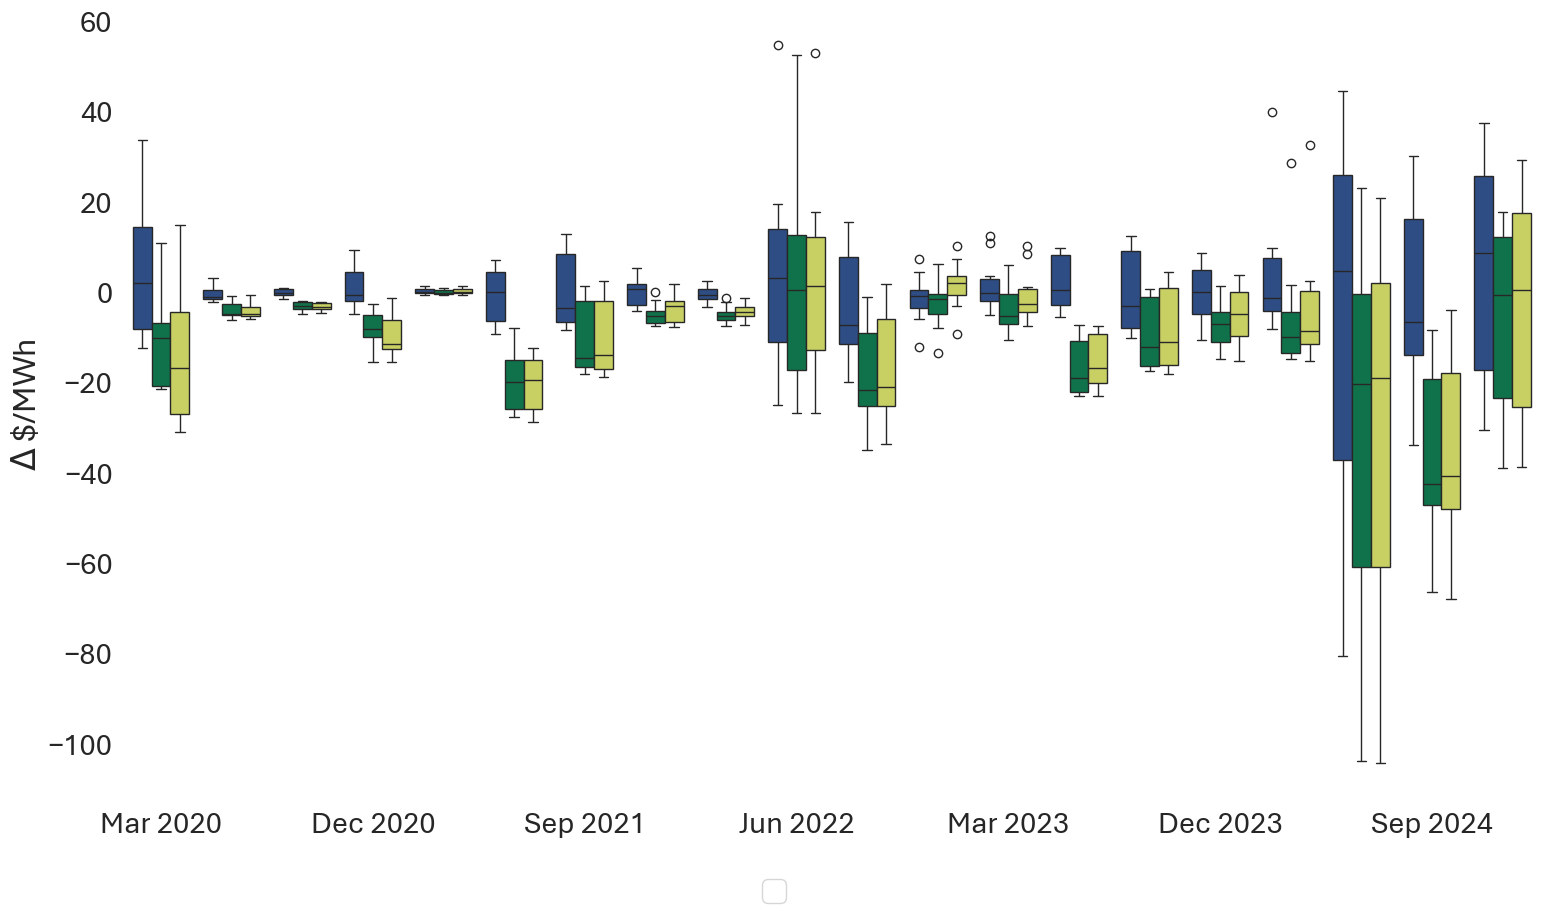

NSW Wind month
Loading monthly NSW wind data ...


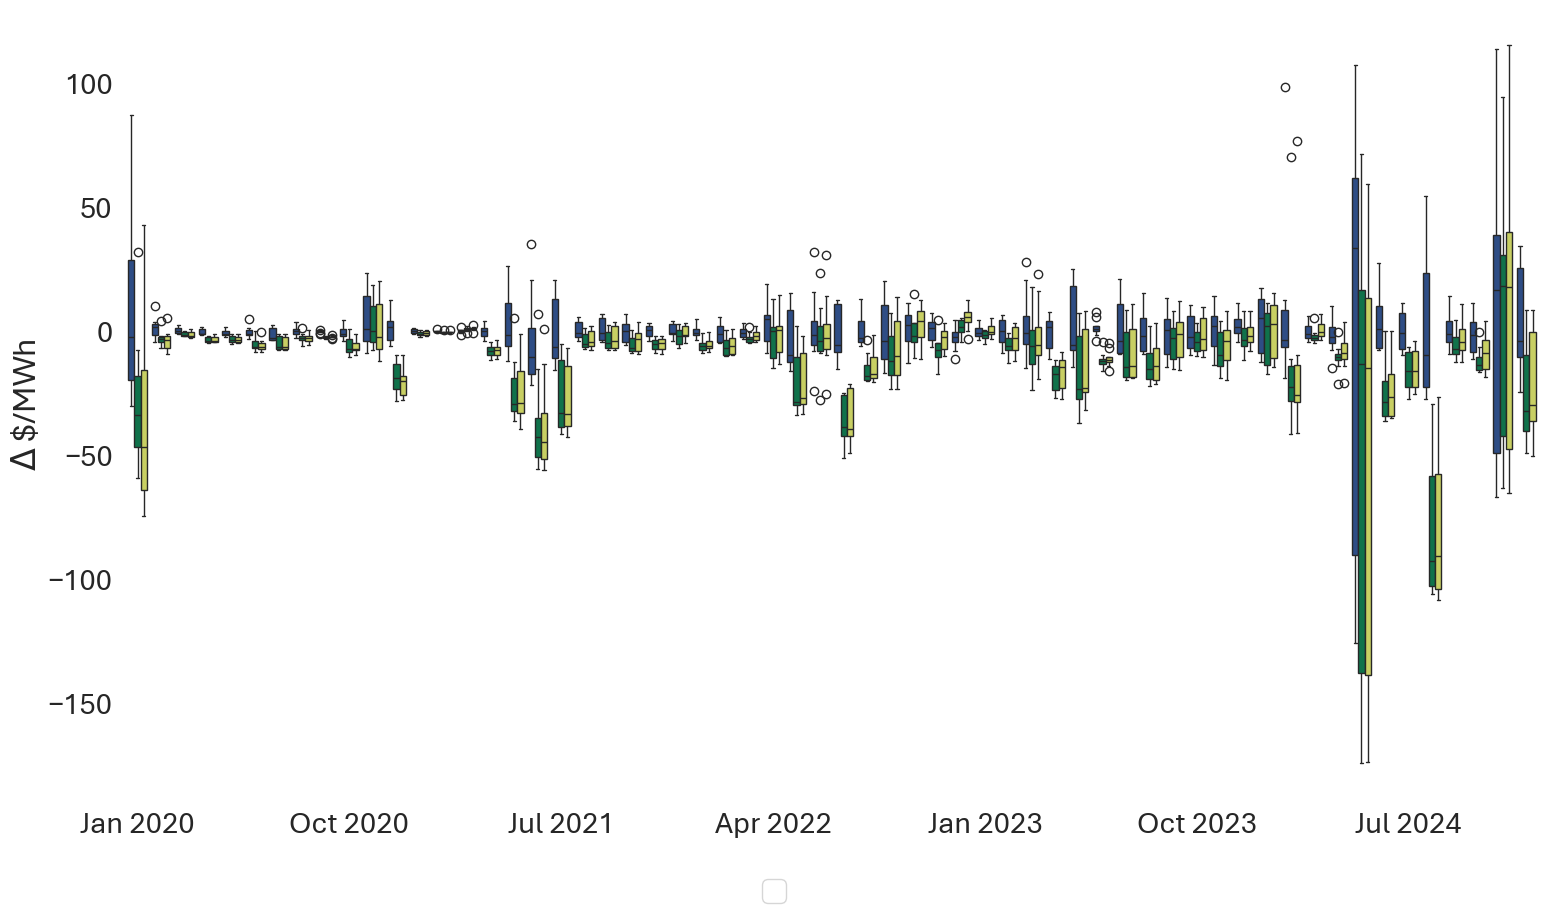

NSW Wind week
Loading weekly NSW wind data ...


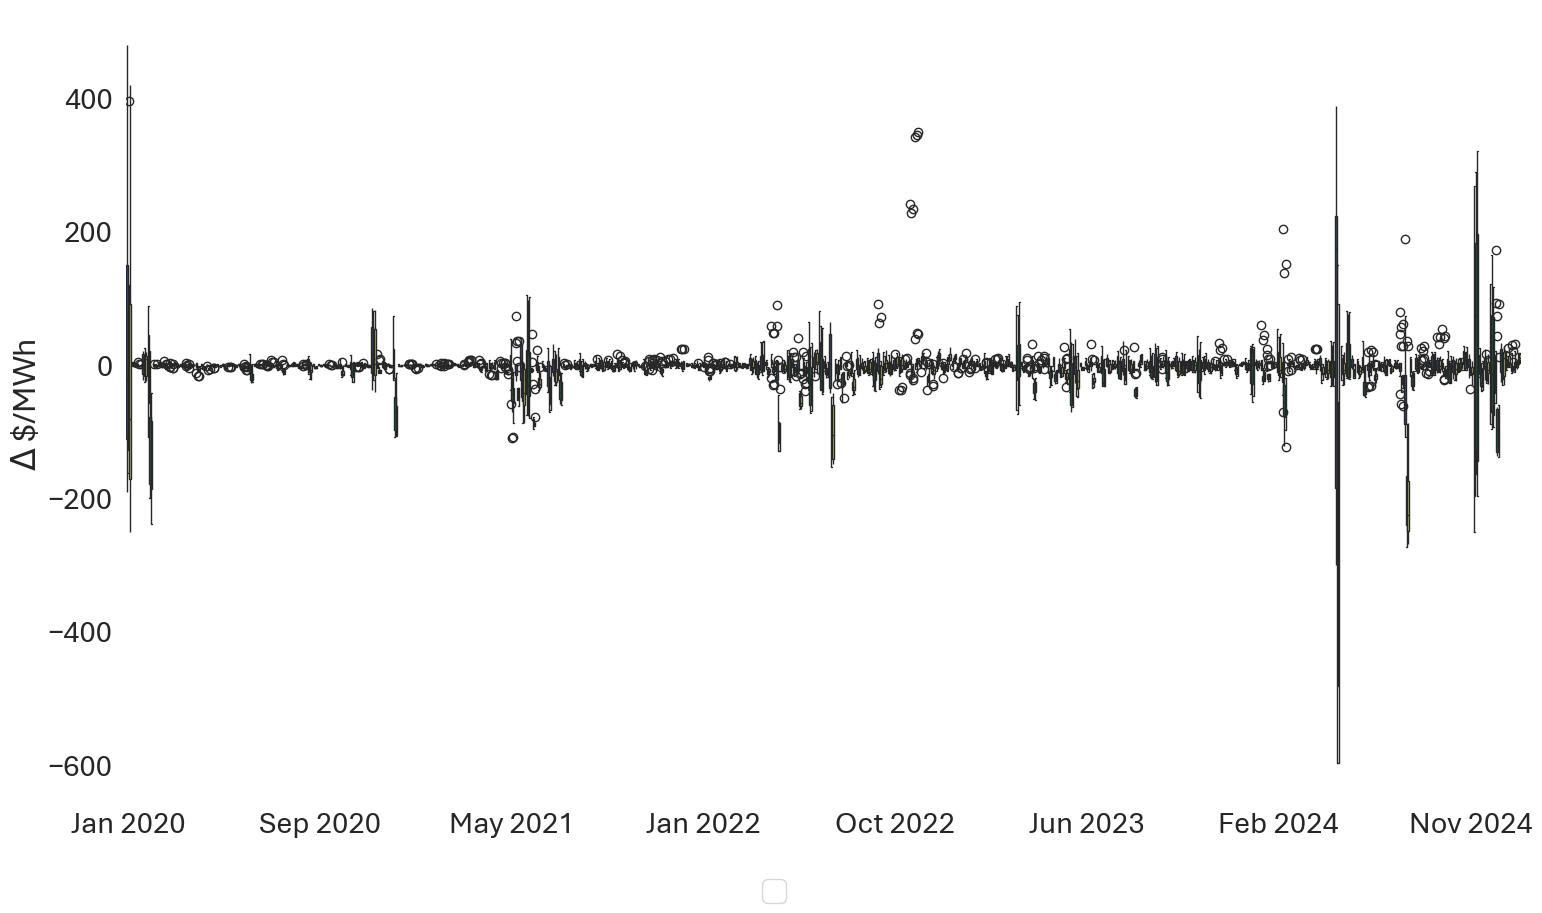

NSW Solar quarter
Loading quarterly NSW solar data ...


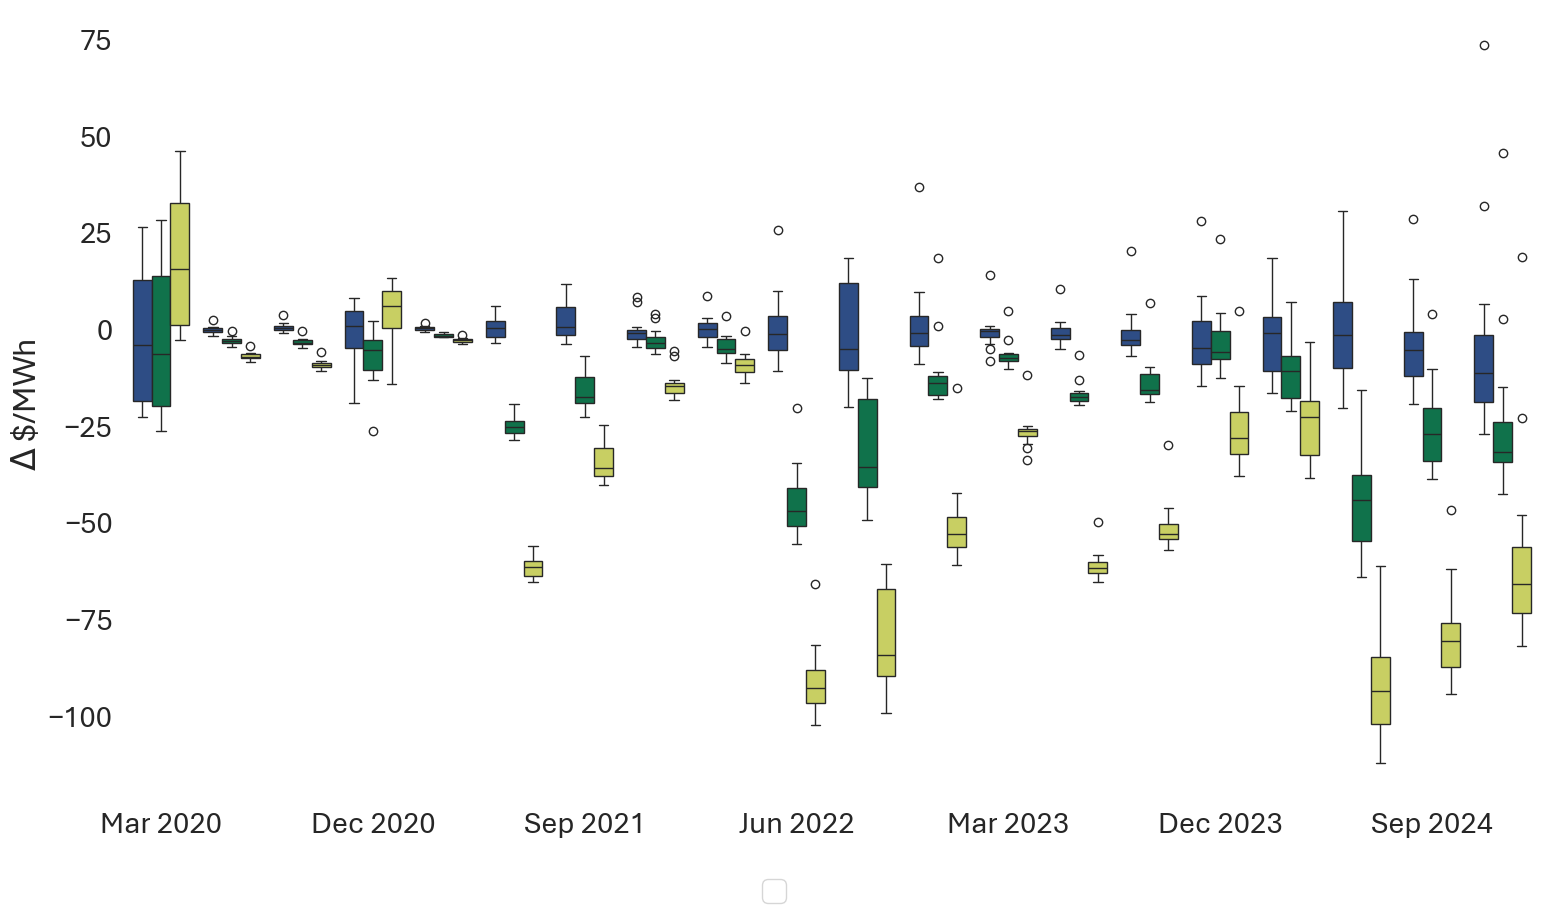

NSW Solar month
Loading monthly NSW solar data ...


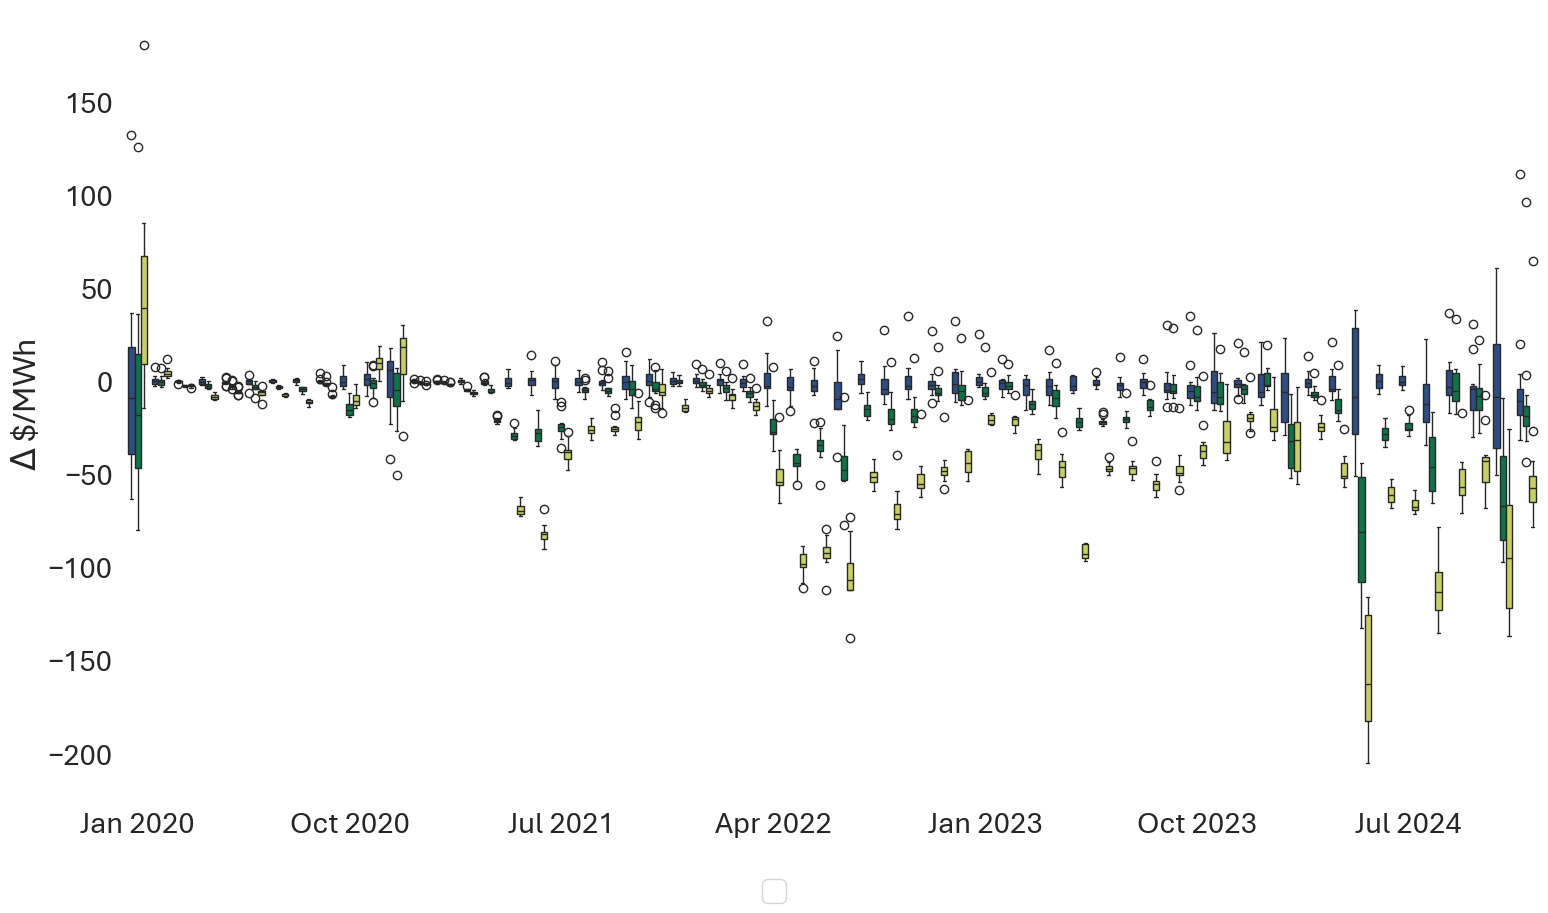

NSW Solar week
Loading weekly NSW solar data ...


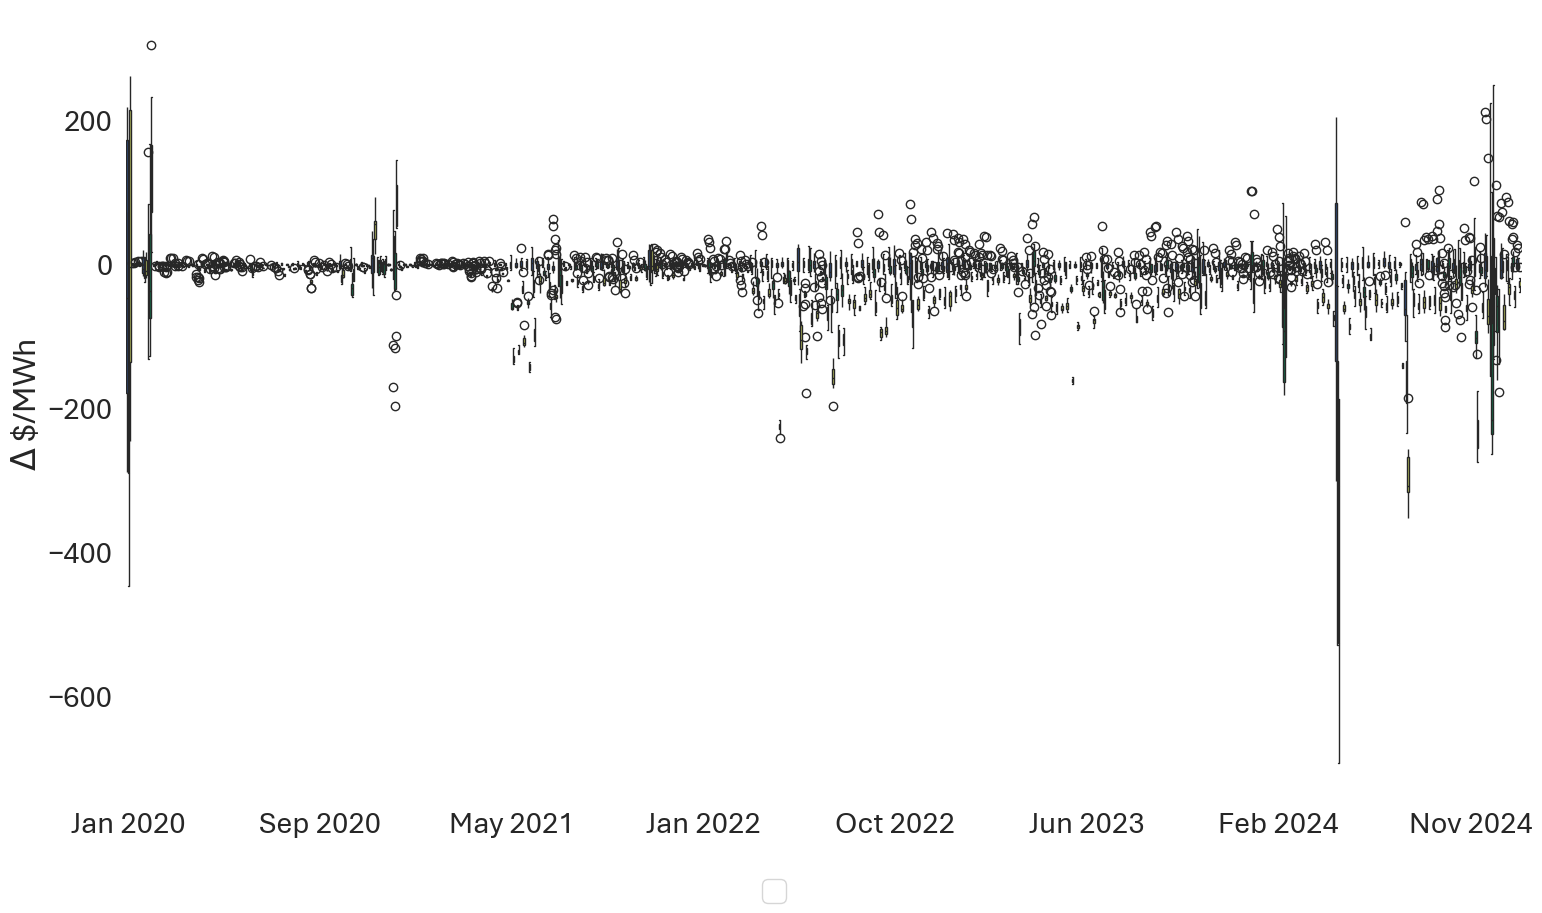

QLD Wind quarter
Loading quarterly QLD wind data ...


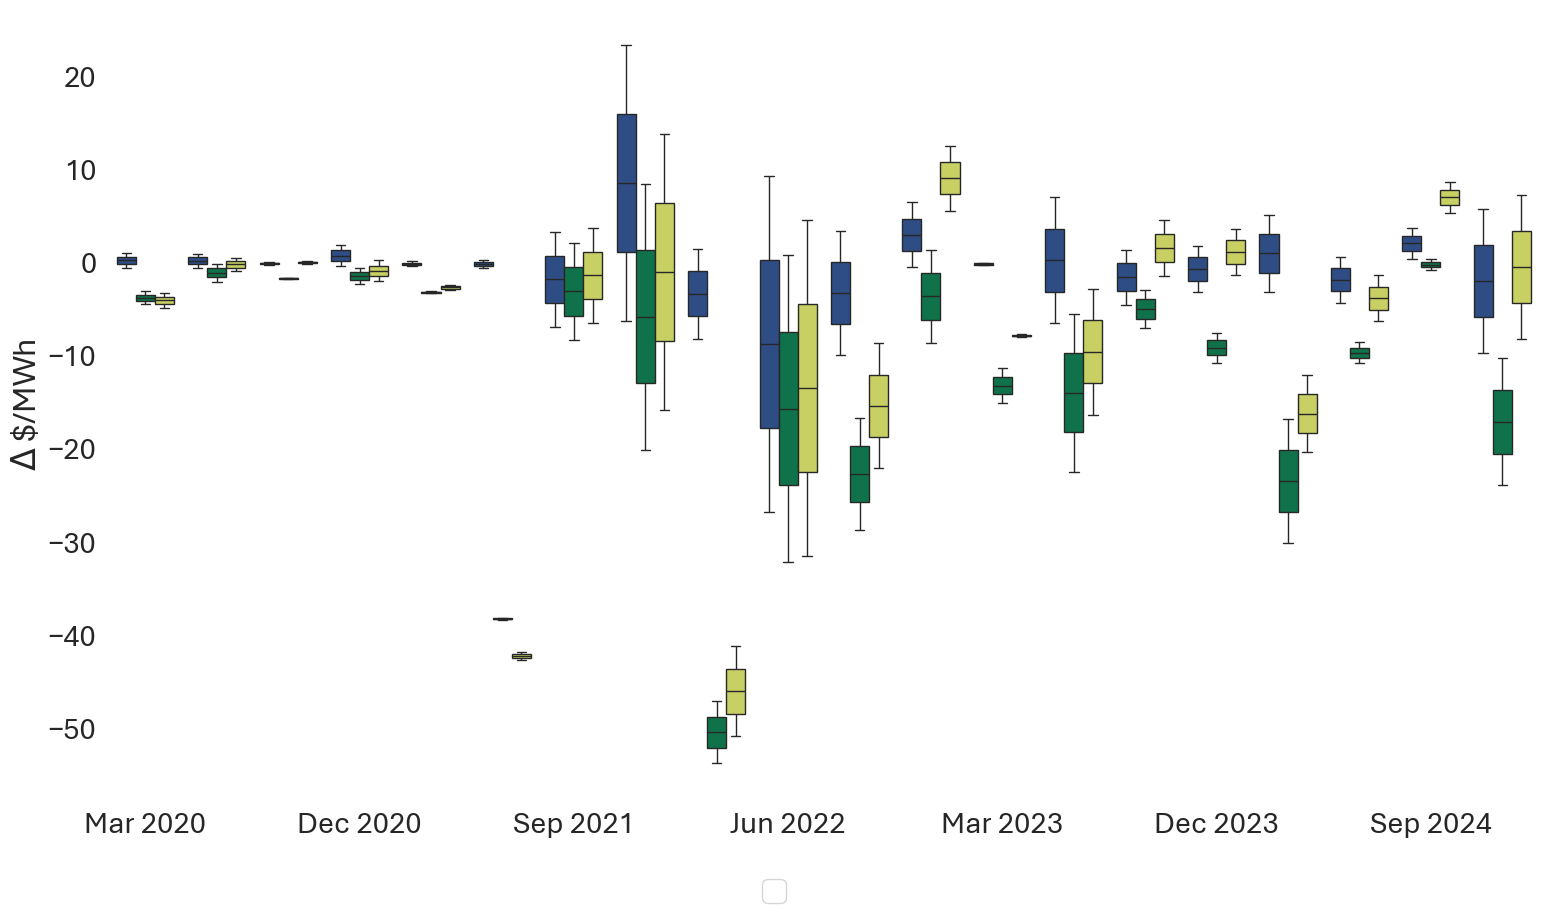

QLD Wind month
Loading monthly QLD wind data ...


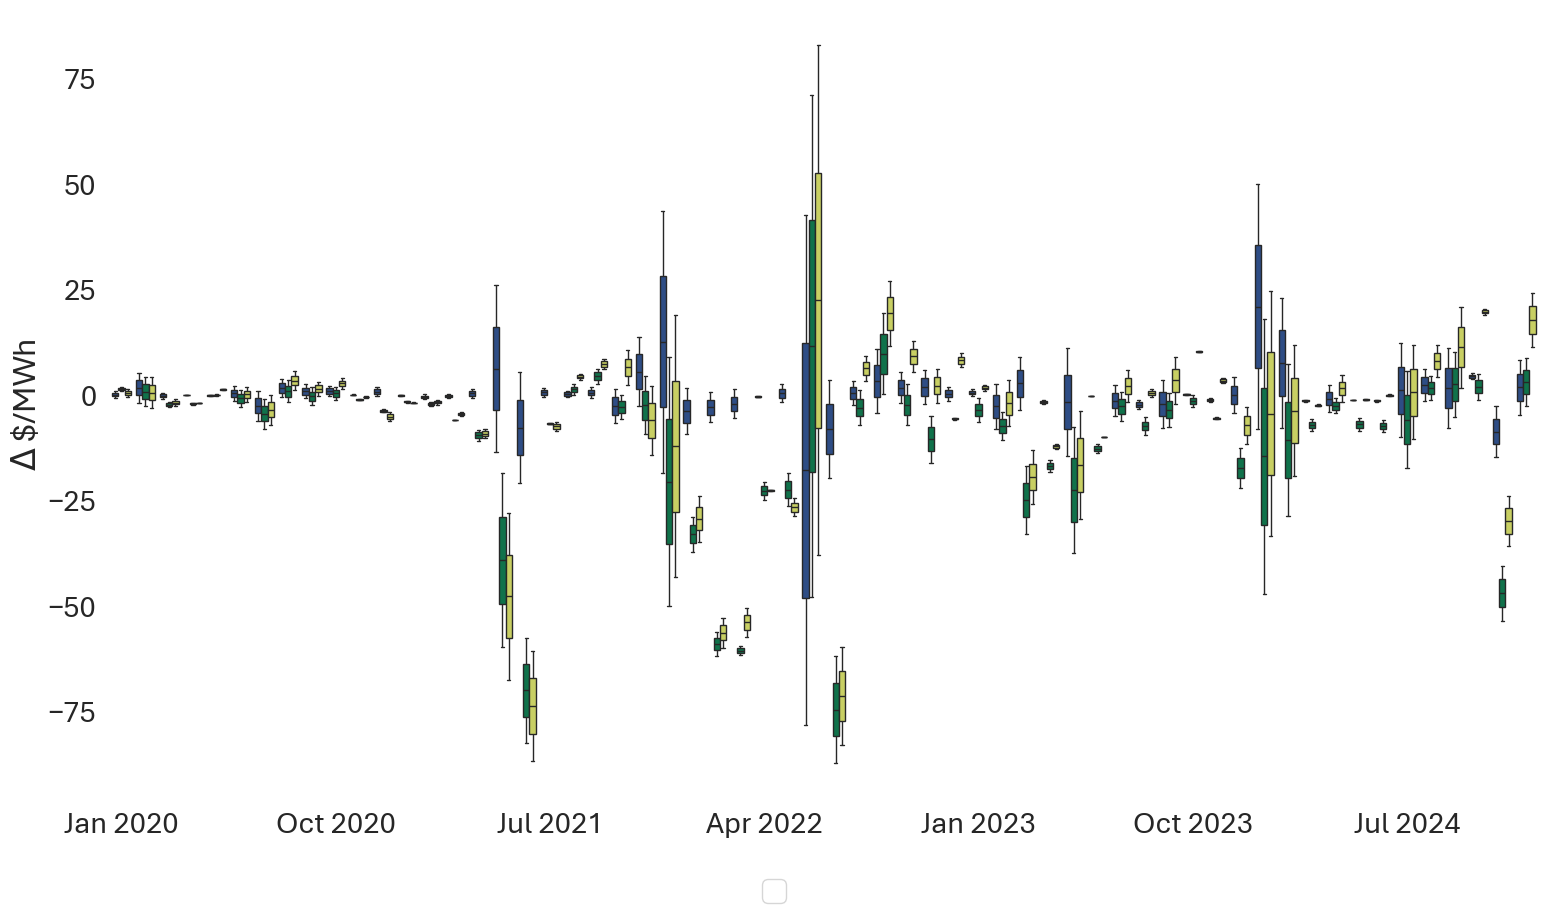

QLD Wind week
Loading weekly QLD wind data ...


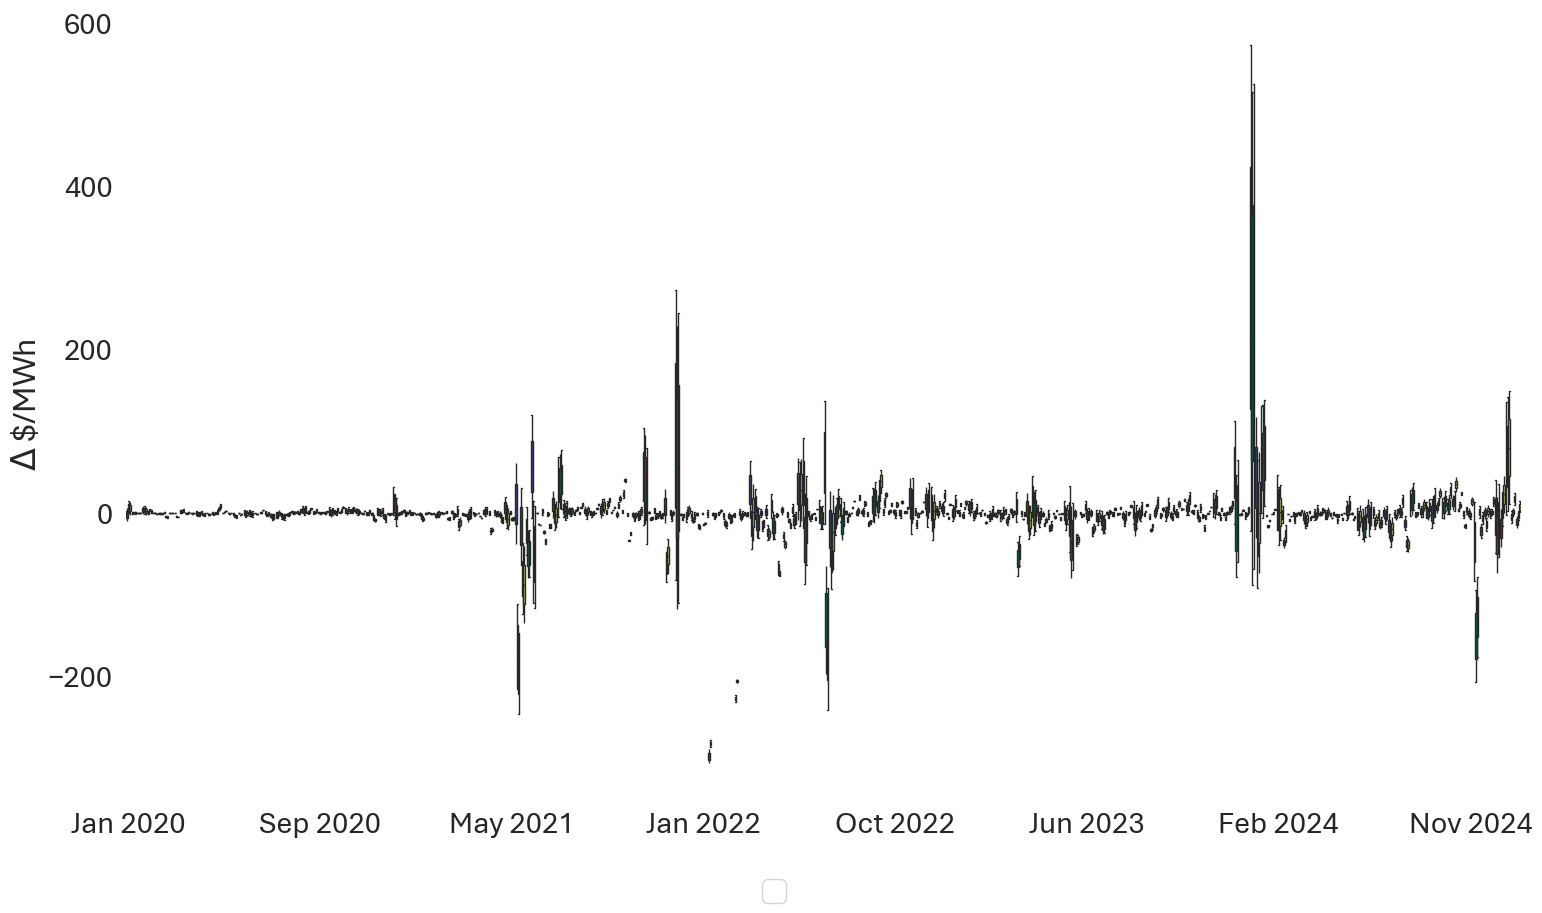

QLD Solar quarter
Loading quarterly QLD solar data ...


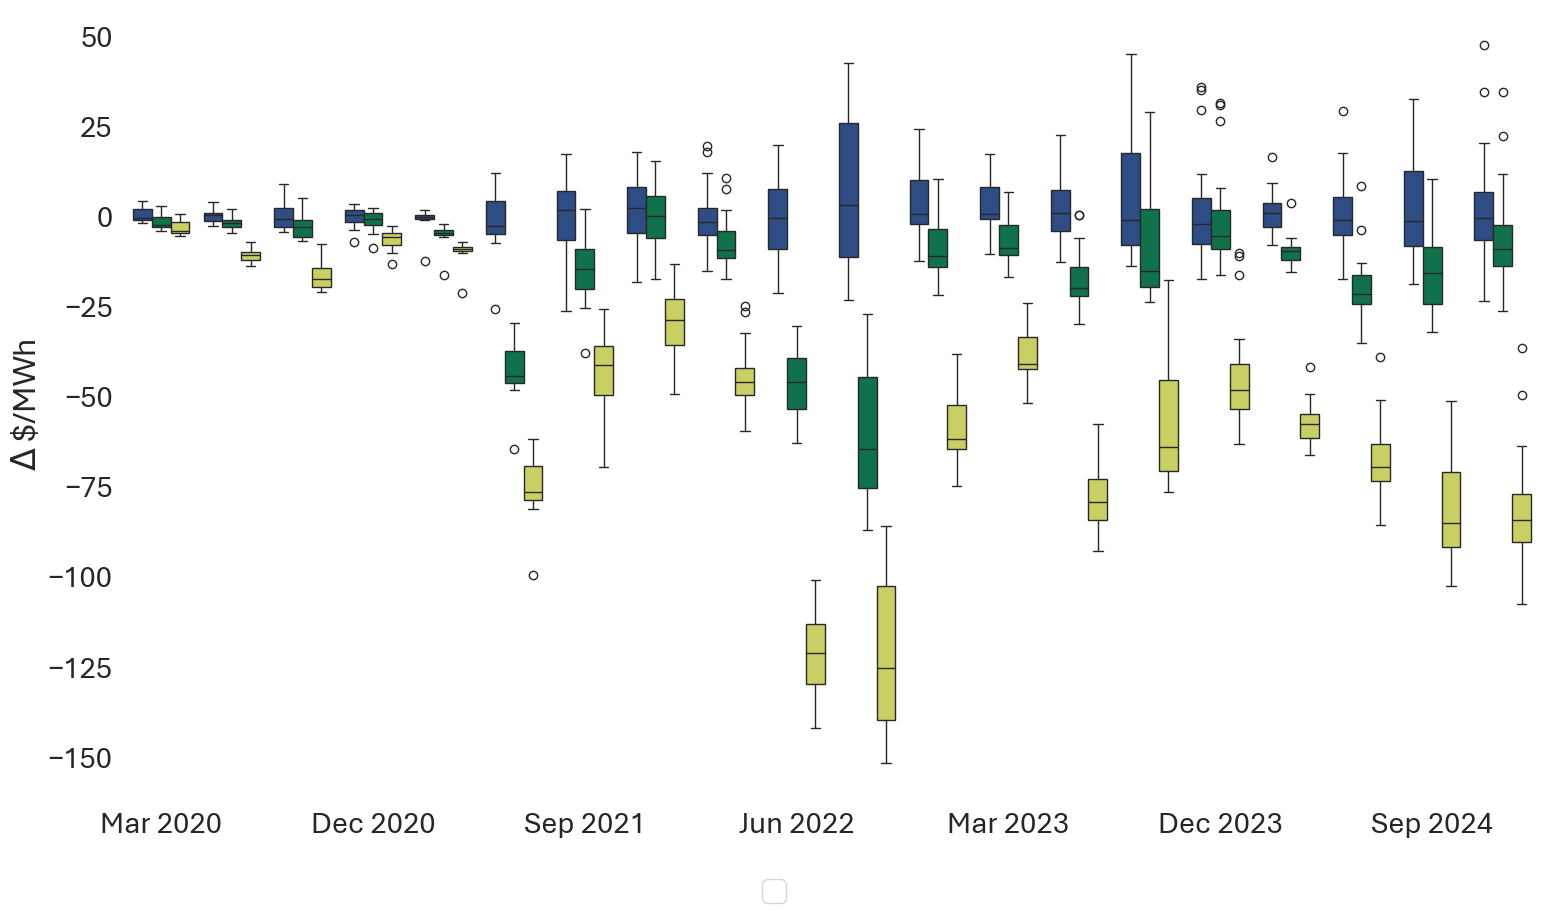

QLD Solar month
Loading monthly QLD solar data ...


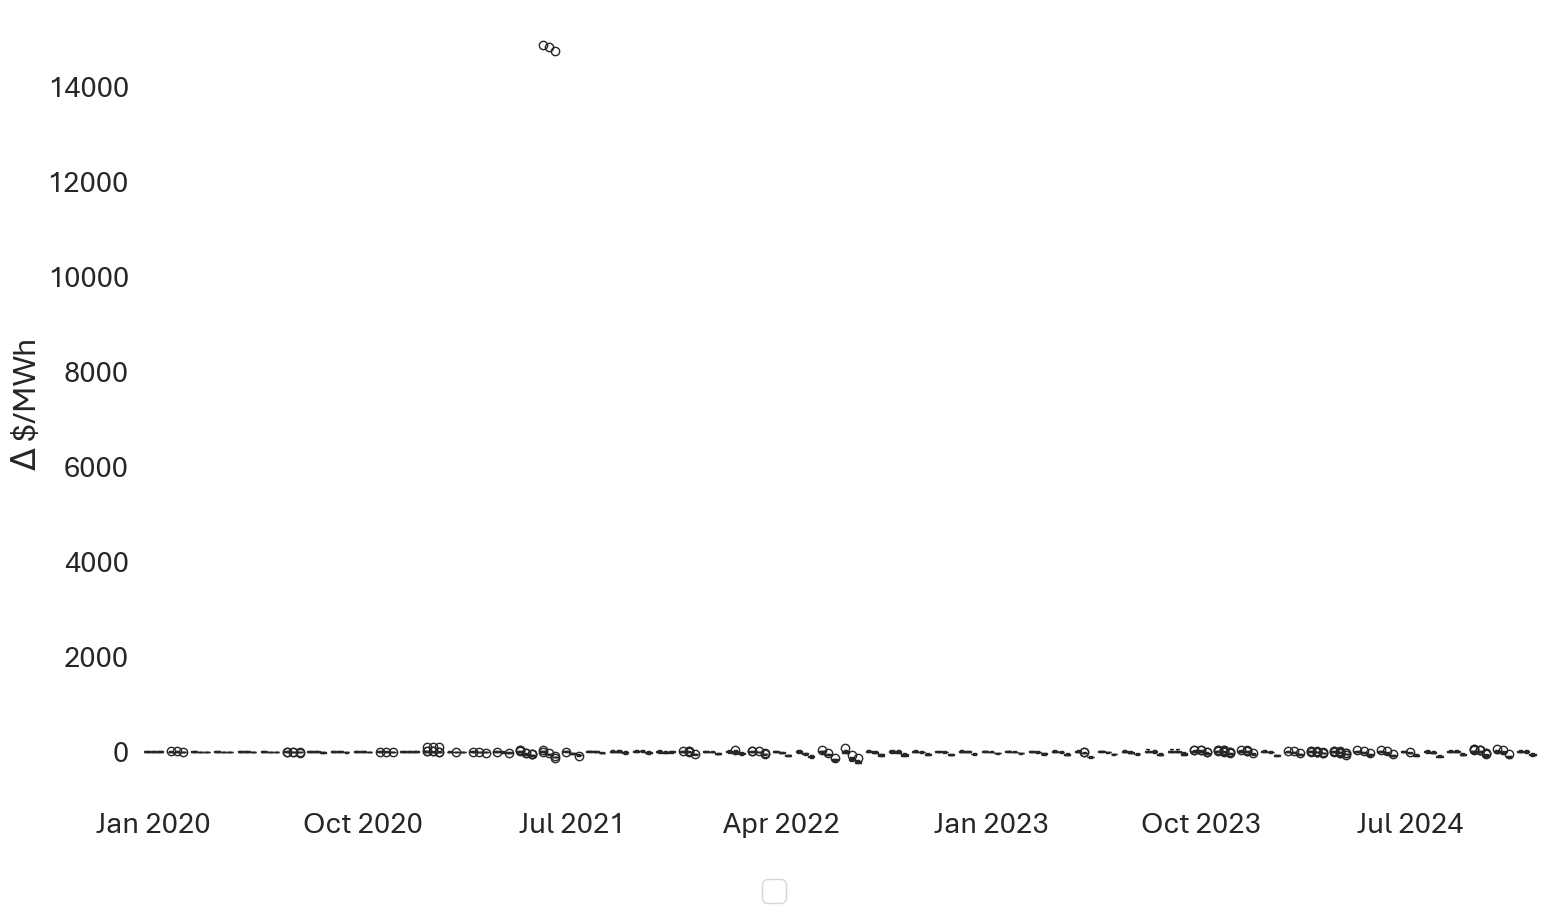

QLD Solar week
Loading weekly QLD solar data ...


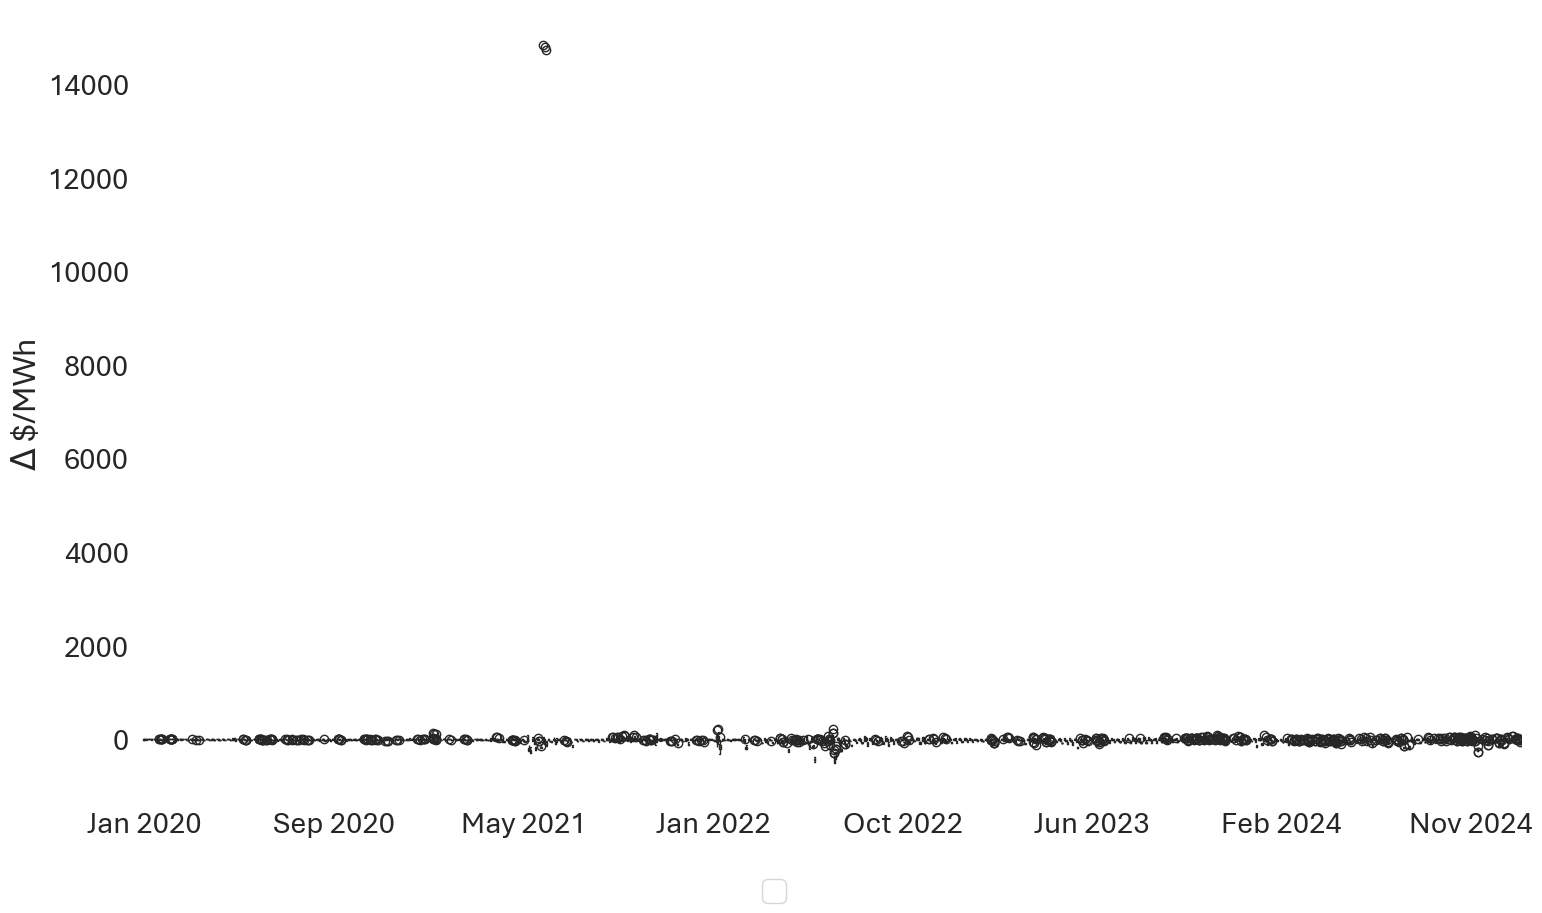

SA Wind quarter
Loading quarterly SA wind data ...


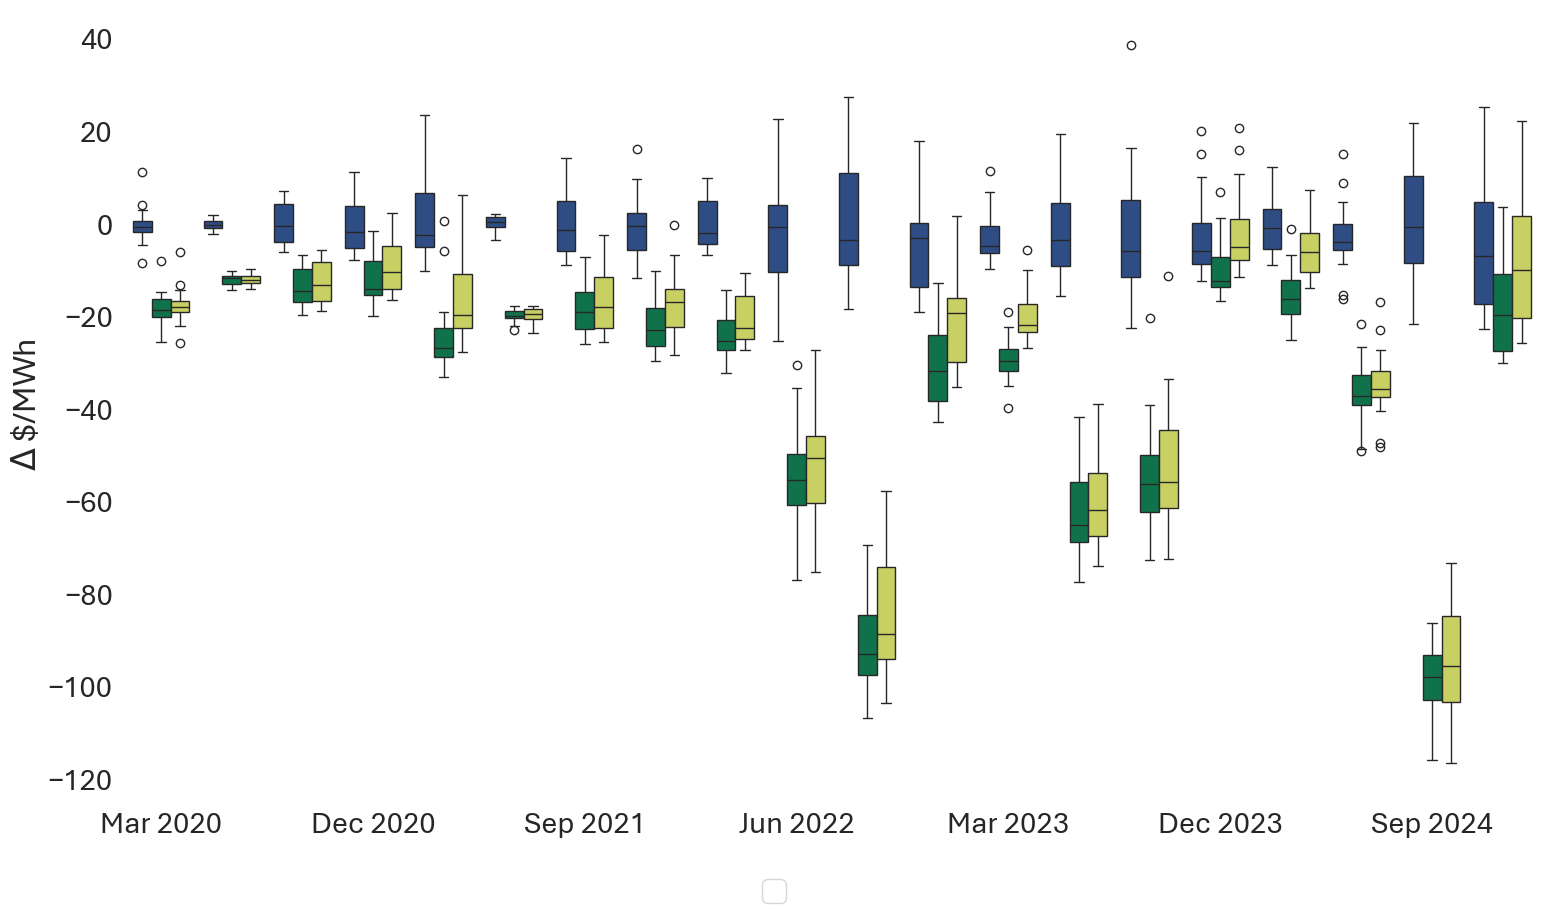

SA Wind month
Loading monthly SA wind data ...


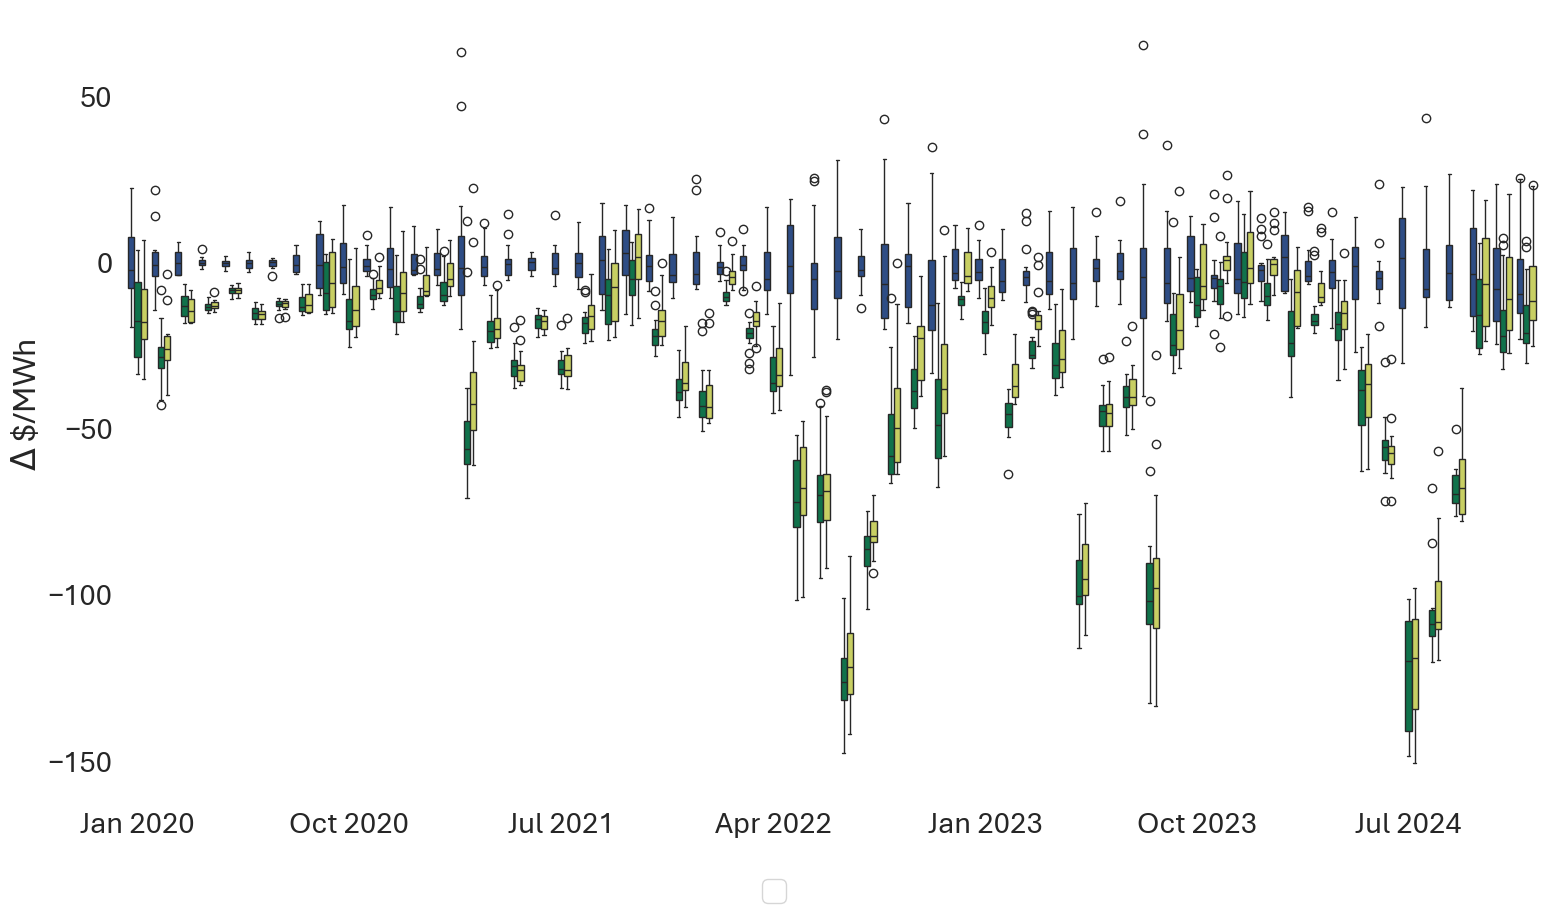

SA Wind week
Loading weekly SA wind data ...


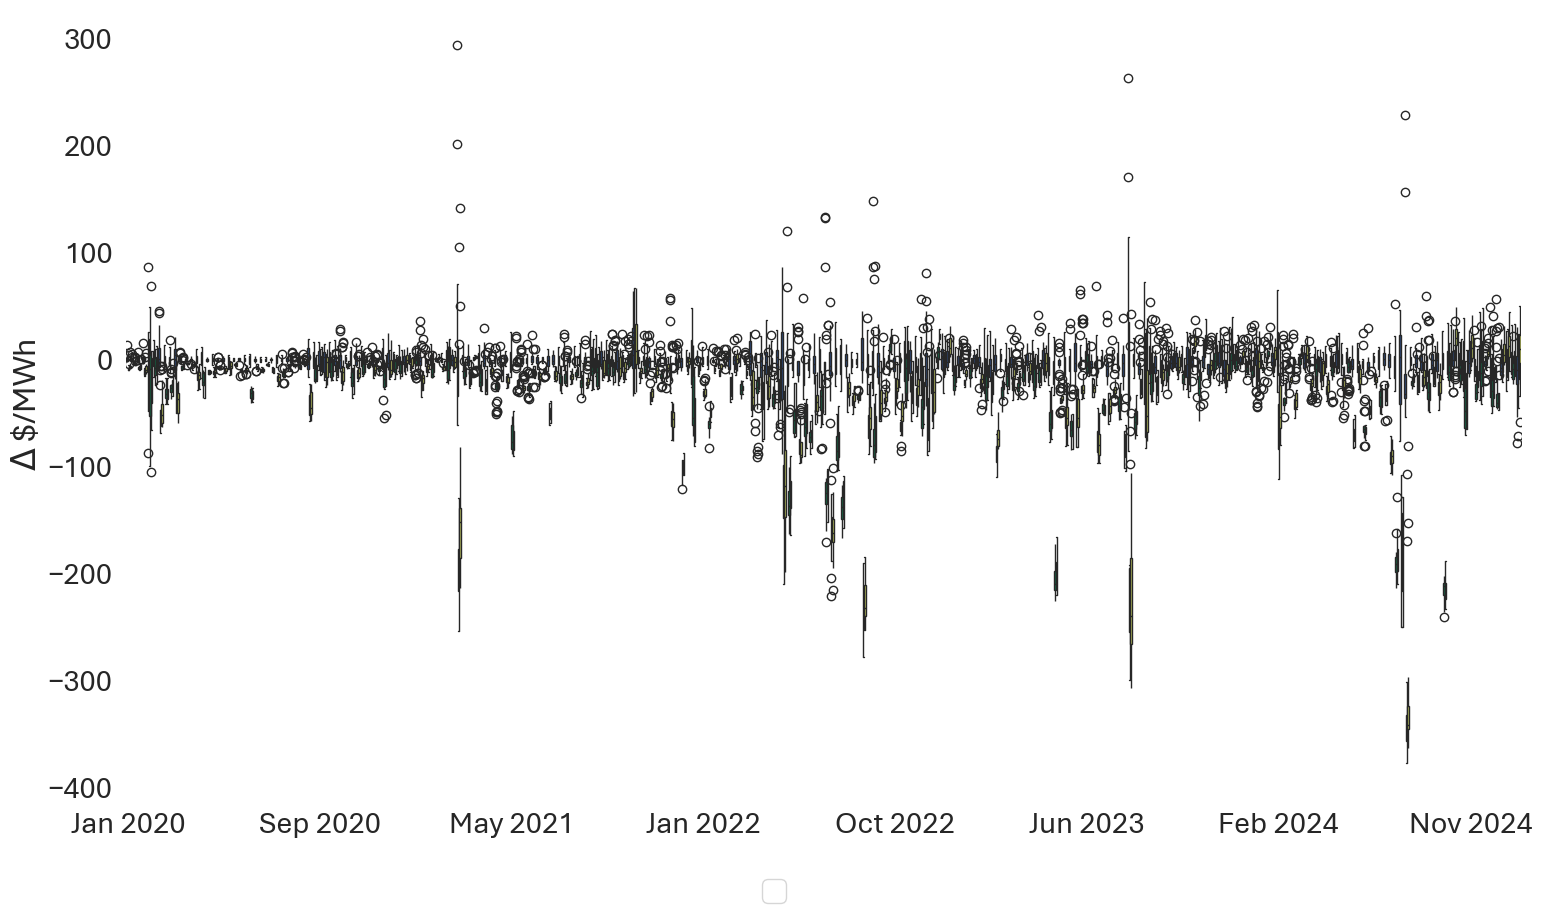

SA Solar quarter
Loading quarterly SA solar data ...


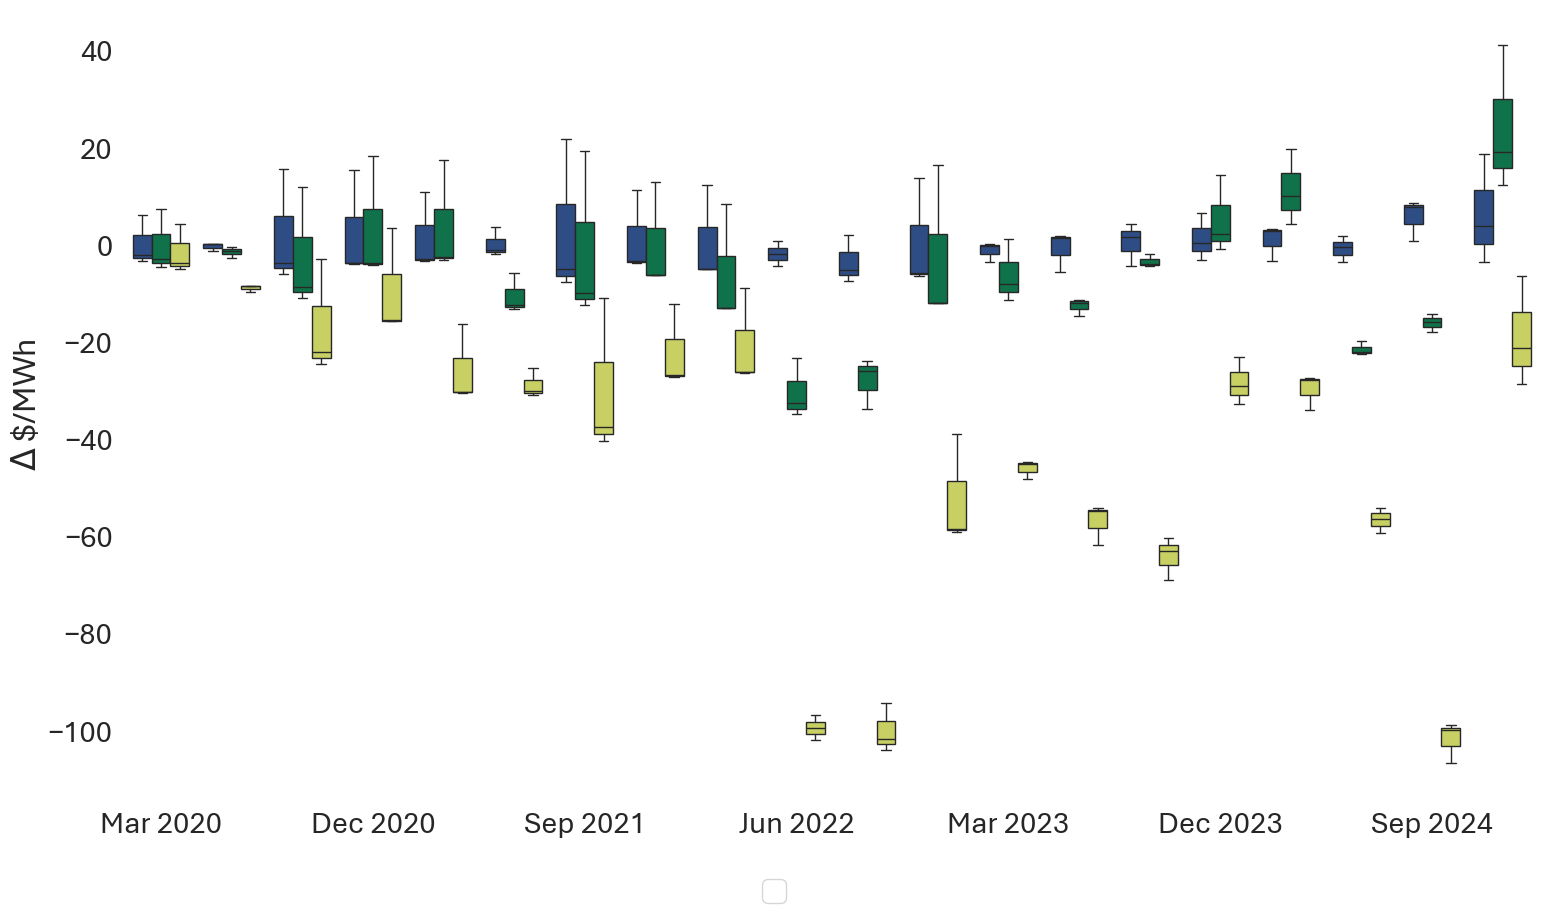

SA Solar month
Loading monthly SA solar data ...


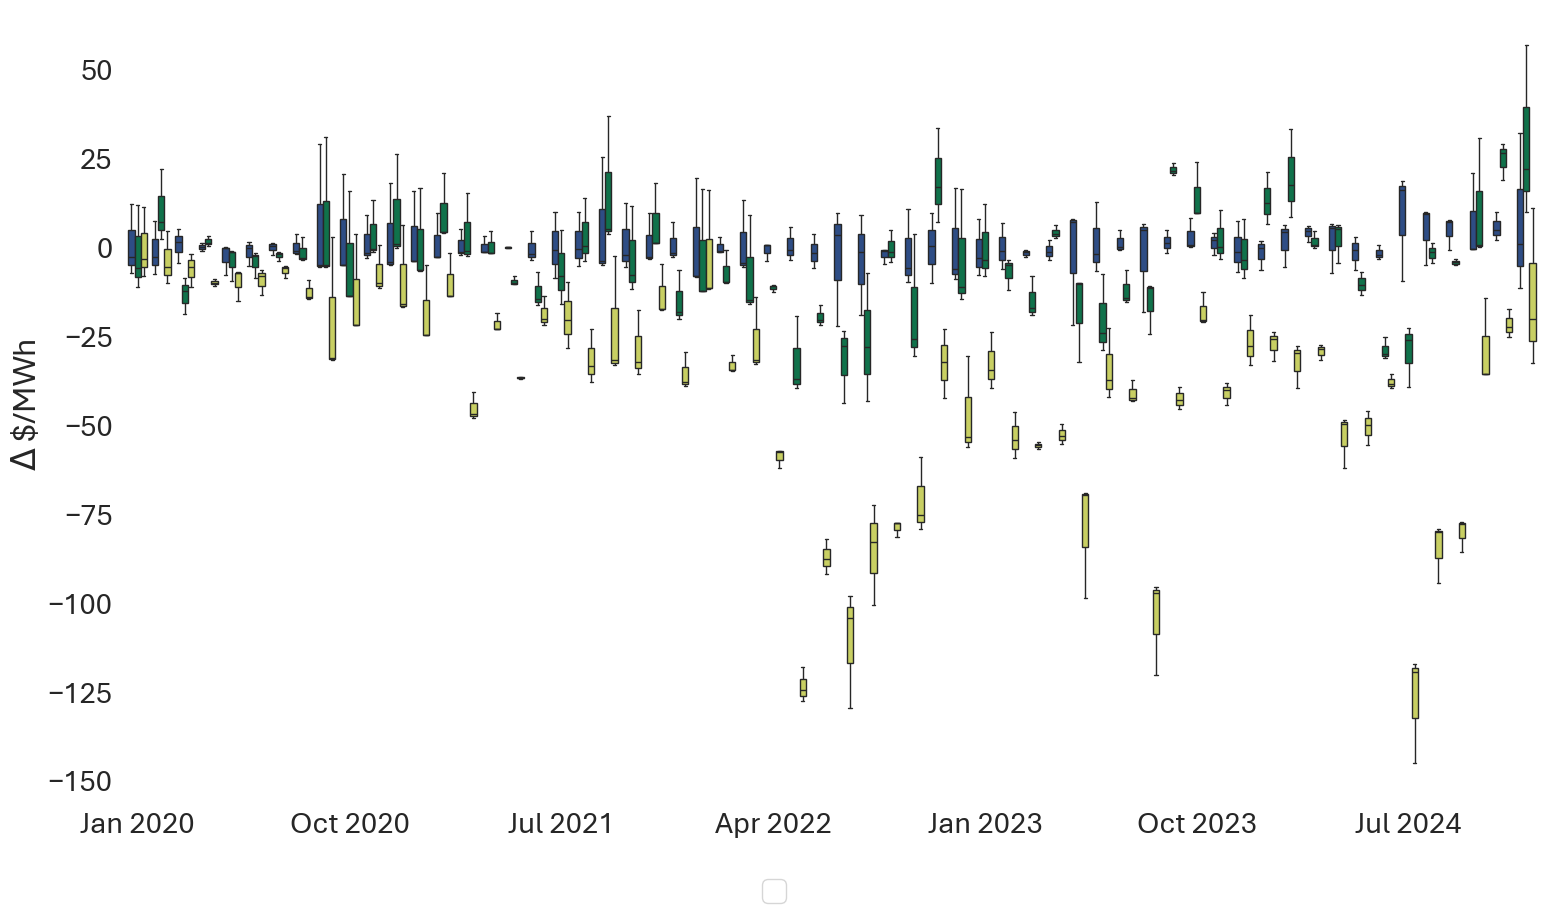

SA Solar week
Loading weekly SA solar data ...


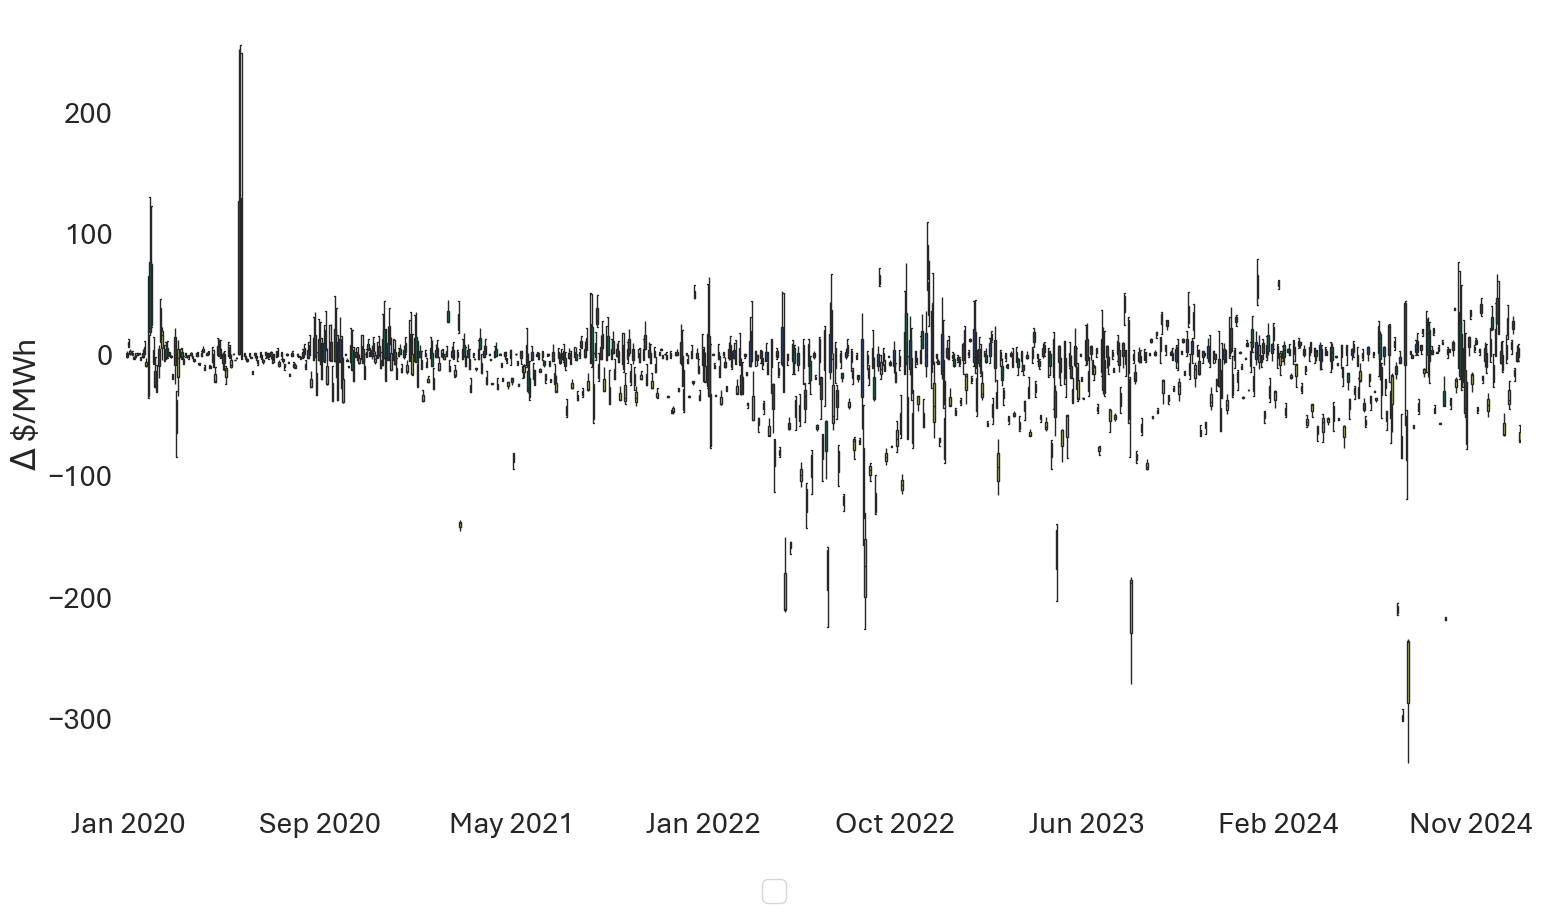

VIC Wind quarter
Loading quarterly VIC wind data ...


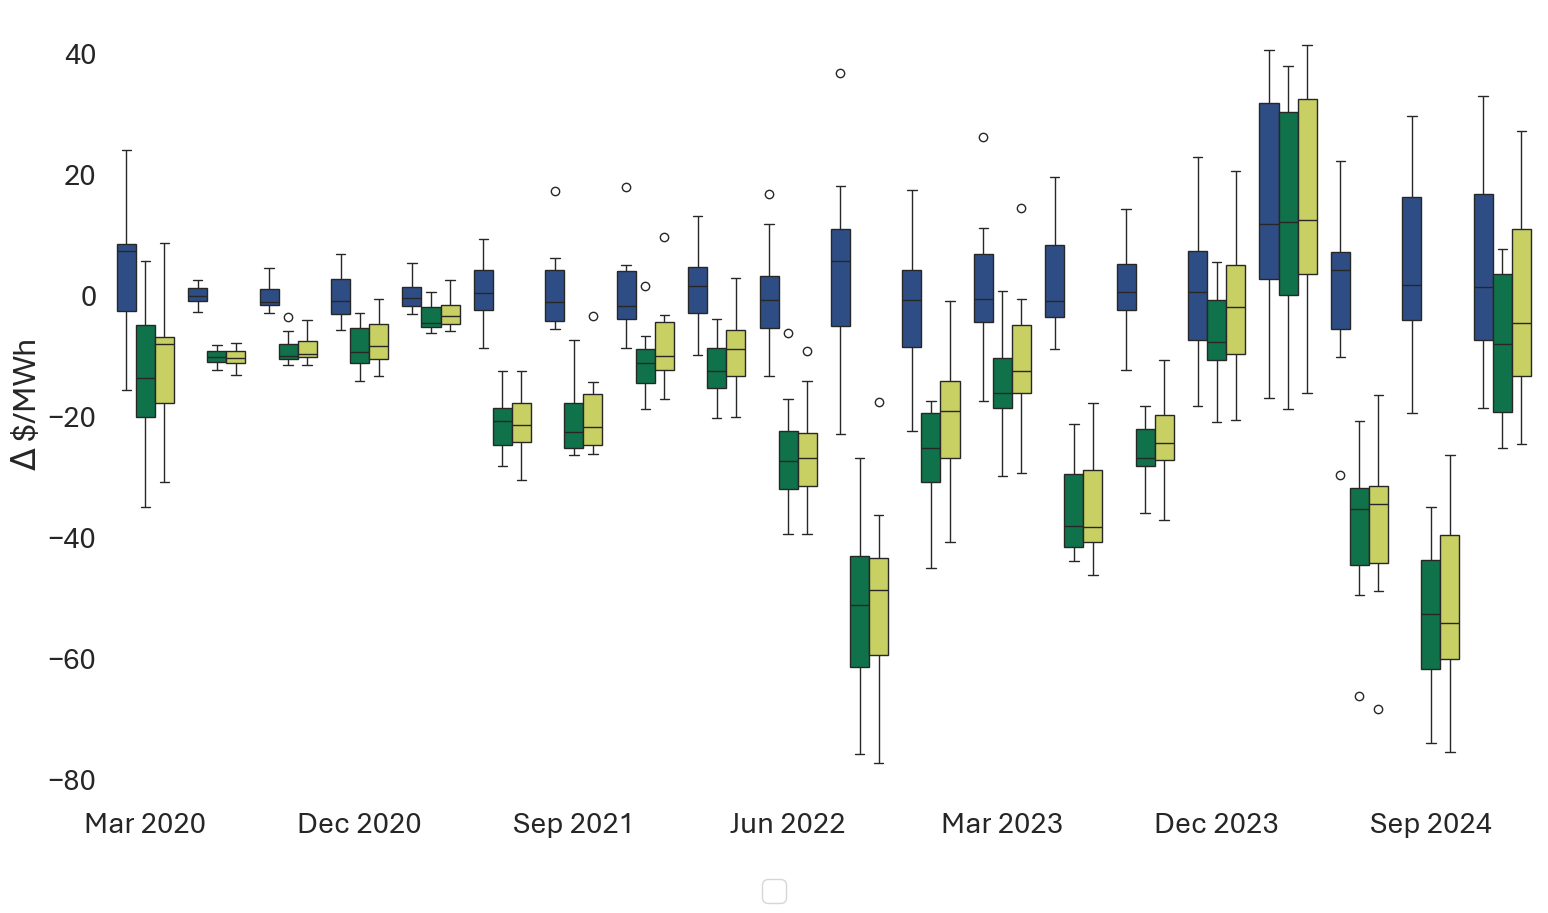

VIC Wind month
Loading monthly VIC wind data ...


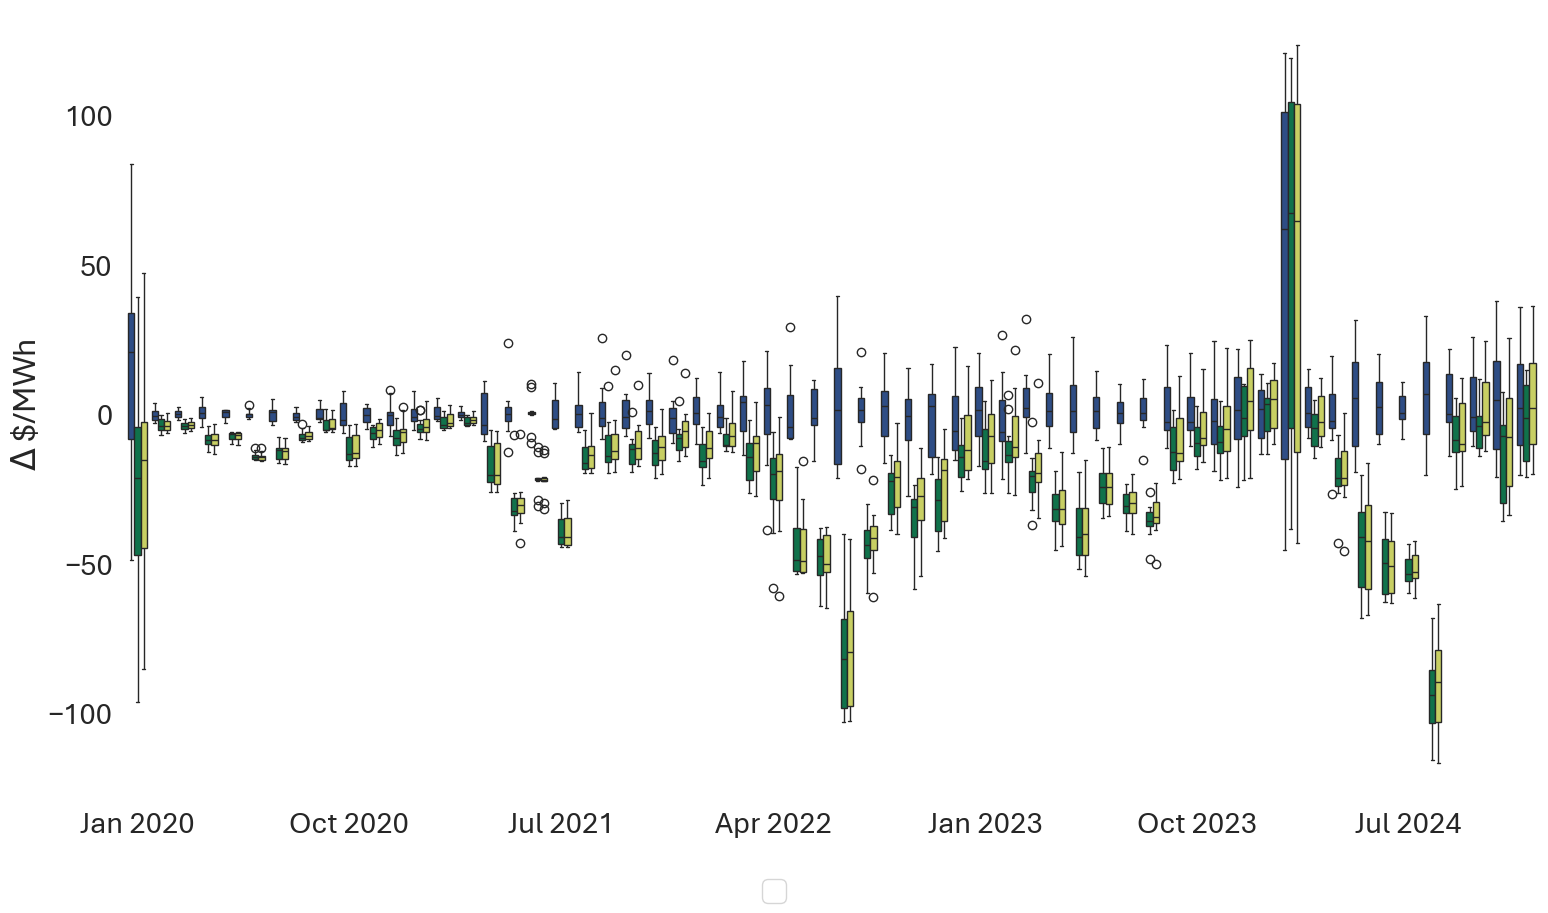

VIC Wind week
Loading weekly VIC wind data ...


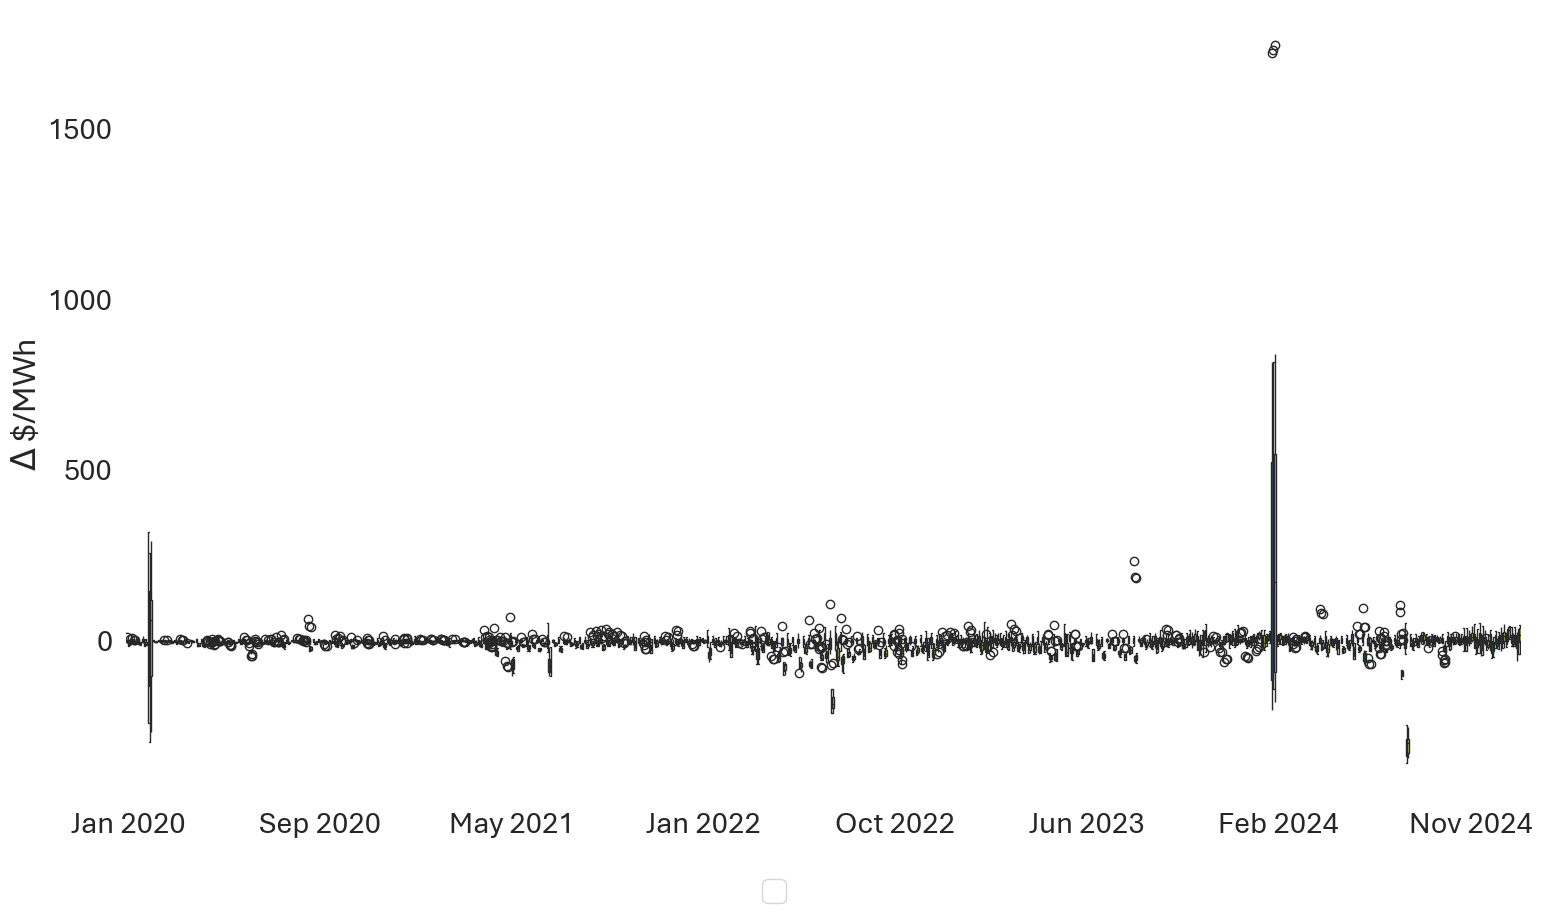

VIC Solar quarter
Loading quarterly VIC solar data ...


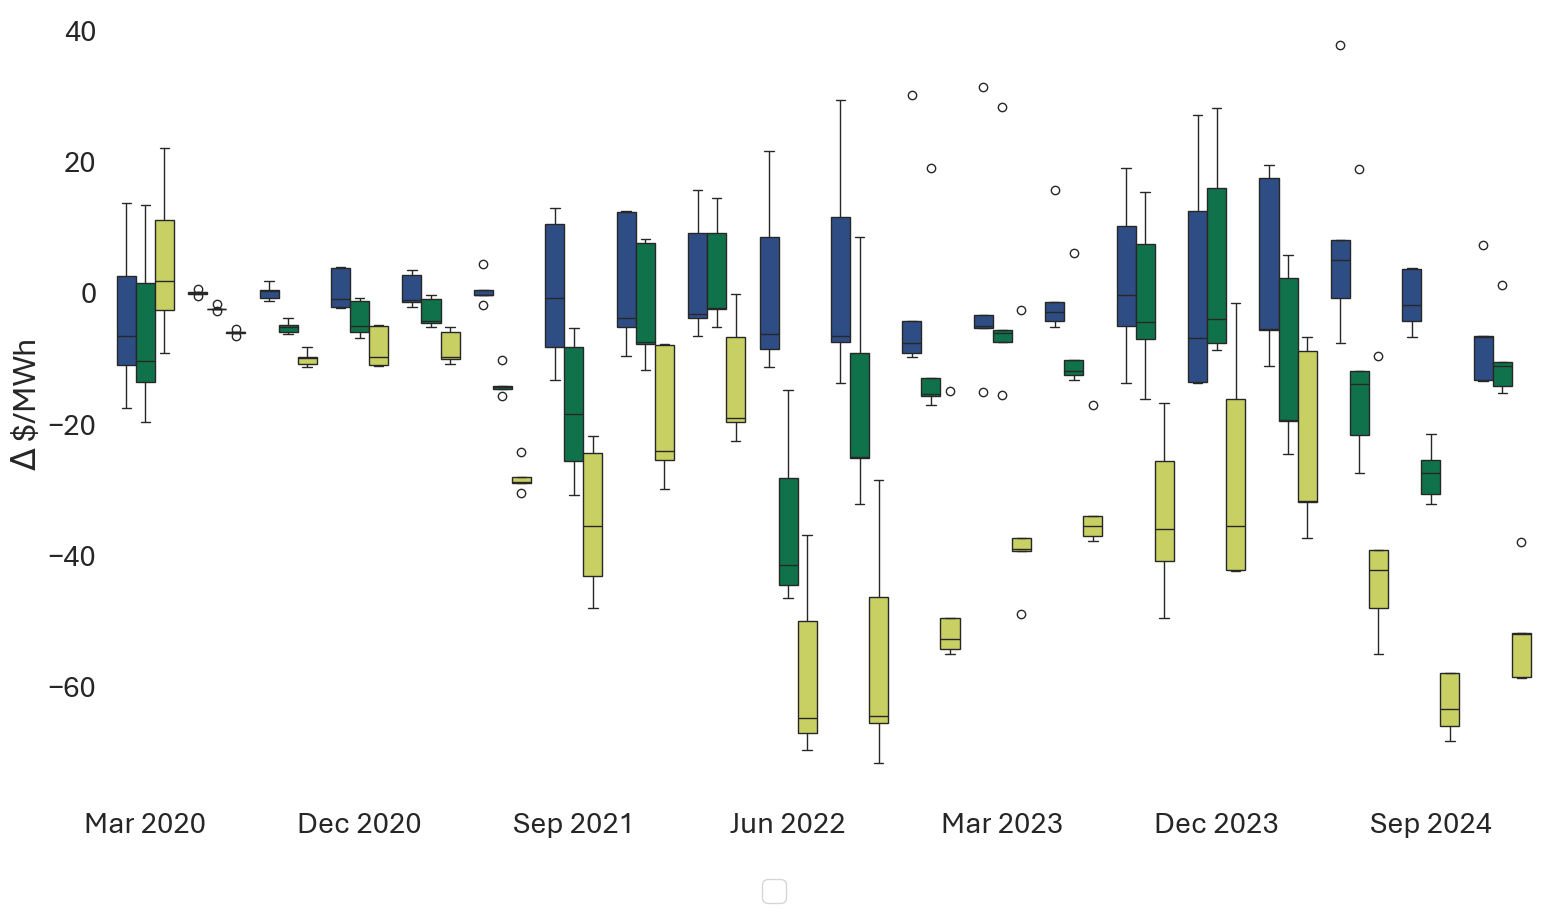

VIC Solar month
Loading monthly VIC solar data ...


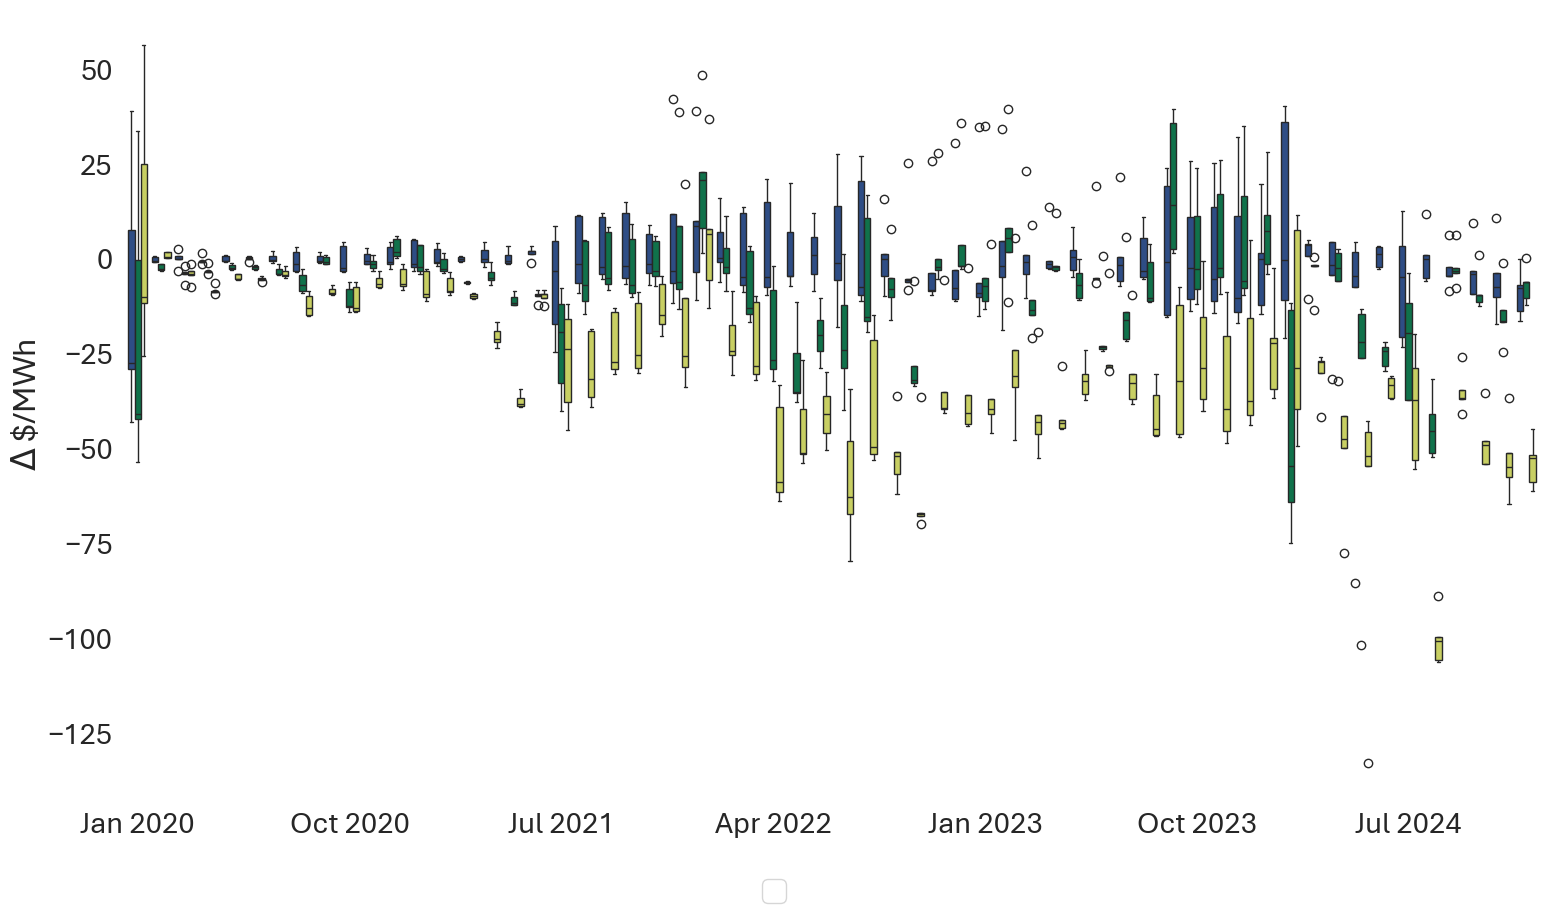

VIC Solar week
Loading weekly VIC solar data ...


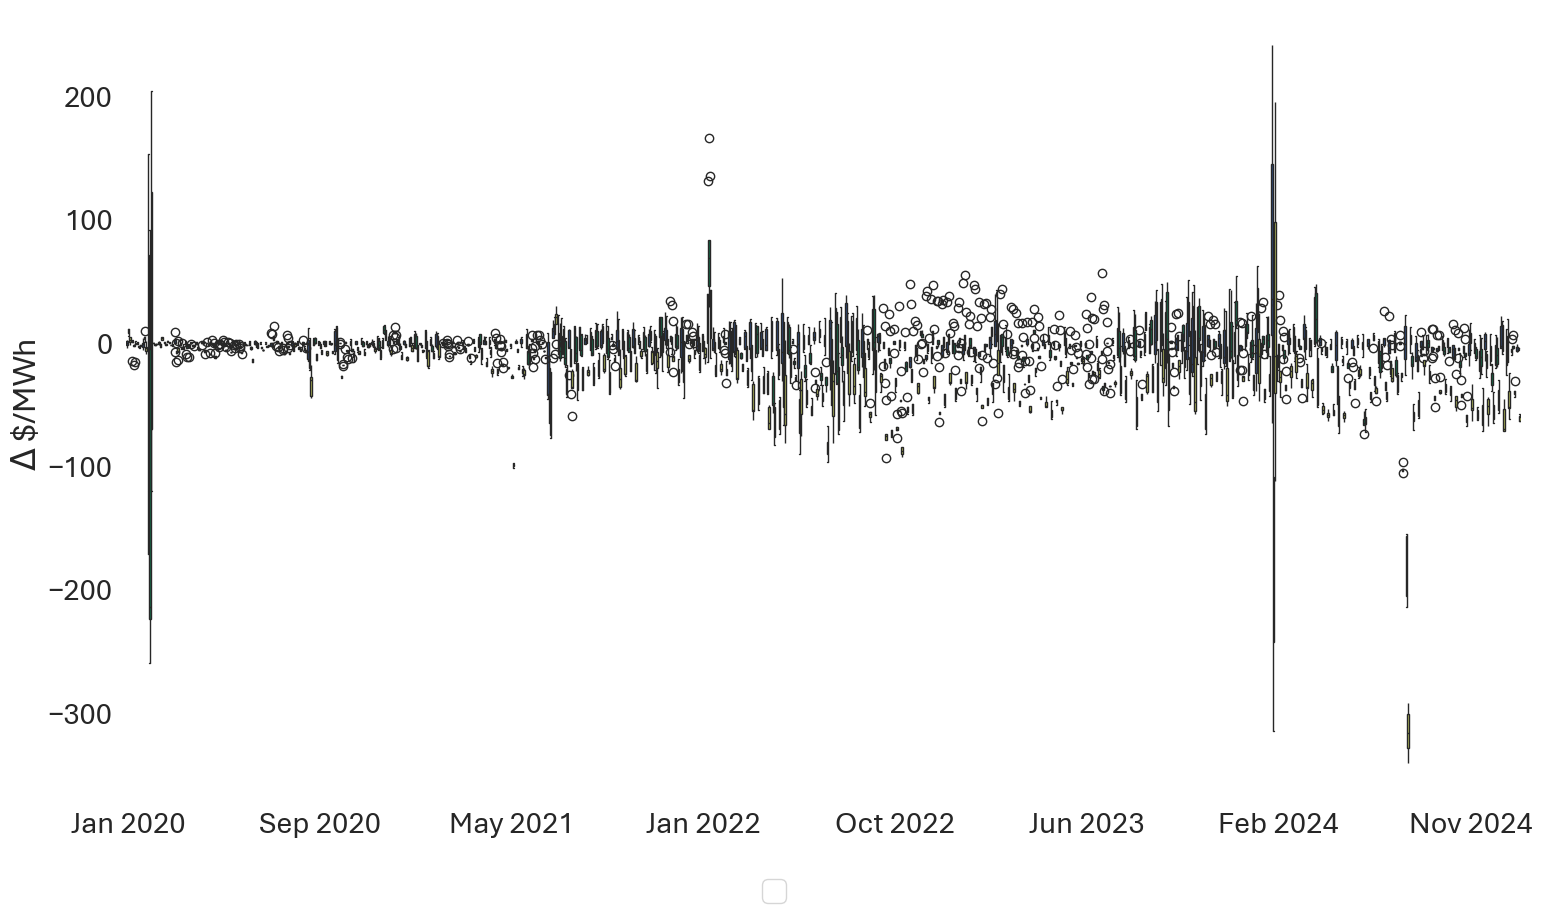

In [46]:
for region in regions:
    for tech in ["Wind", "Solar"]:
        for i, period in enumerate(["quarter", "month", "week"]):
            print(region, tech, period)
            fig, ax = plt.subplots(
                figsize=(16, 9),
                tight_layout=True)
            data_path = os.path.join(
                data_dir,
                f"{region}_{tech.lower()}_price_deltas_{period}ly.csv")
            if os.path.exists(data_path):
                print(f"Loading {period}ly {region} {tech.lower()} data ...")
                chart_data = pd.read_csv(
                    data_path,
                    parse_dates=["Period"])
            else:                
                chart_data = generator_analysis(region, tech, period=period)
                print("Saving data to file ...")
                chart_data.to_csv(data_path, index=False)
            sns.boxplot(
                data=chart_data,
                ax=ax,
                x="Period",
                y="Delta",
                hue="Contract",
                palette=["C1", "C2", "C4"])
            for frame in ["top", "right", "bottom", "left"]:
                ax.spines[frame].set_visible(False)
            plt.ylabel(r"$\Delta$ \$/MWh")
            plt.xlabel(None)
            skip_tick = (3 if period == "quarter" else 9 if period == "month" else 36)            
            ax.set_xticks(ax.get_xticks()[::skip_tick])
            ax.set_xticklabels([f"{chart_data["Period"].unique()[t]:%b %Y}" for t in ax.get_xticks()])
            handles, labels = axis.get_legend_handles_labels()
            ax.get_legend().remove()
            fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3)
            plt.show()

In [ ]:
chart_data

,Period,DUID,Delta,Contract
0,2020-01-05,BLUFF1,0.223705,Ex-post DWA
1,2020-01-12,BLUFF1,0.232241,Ex-post DWA
2,2020-01-19,BLUFF1,-1.605905,Ex-post DWA
3,2020-01-26,BLUFF1,-3.094703,Ex-post DWA
4,2020-02-02,BLUFF1,-47.736128,Ex-post DWA
...,...,...,...,...
12571,2024-12-08,WGWF1,-45.554096,ToD blocks
12572,2024-12-15,WGWF1,-6.645727,ToD blocks
12573,2024-12-22,WGWF1,-1.872303,ToD blocks
12574,2024-12-29,WGWF1,-10.892313,ToD blocks
